# FarmSight — Notebook 1: Pengolahan Data
**Toko Farm Berkah · Demand Forecasting (ARIMA & Prophet) · Safety Stock · Reorder Point**

Notebook ini **hanya mengolah data** sampai siap dipakai untuk pemodelan dan dashboard Streamlit.
Pemodelan (ARIMA, Prophet, evaluasi MAE/RMSE/MAPE, Safety Stock, ROP) dikerjakan di notebook terpisah.

Alur mengikuti jurnal (Data Cleaning → Data Transformation → Data Integration → Data Storage),
disesuaikan dengan teknologi yang dipakai (Python di Google Colab, pandas, SQLite untuk penyimpanan),
dengan satu tambahan: **pemisahan train / test dan penanganan outlier**.

**Kenapa cuma train/test, tanpa validation?** Data historisnya kecil (±700 baris transaksi utk 38 produk).
Menyisihkan validation lagi akan memotong train yang sudah sedikit itu jadi makin sedikit. Tuning
hyperparameter tetap dilakukan dengan benar (tidak "mengintip" test), caranya lewat *rolling-origin
backtest* **di dalam train sendiri** (lihat Notebook 2, Tahap 3) — bukan lewat split terpisah.

| Tahap | Isi | Output |
|---|---|---|
| 0 | Muat data & profil awal | temuan awal |
| 1 | **Data Cleaning** (aturan validasi, penyeragaman nama produk, format angka & tanggal) | data bersih + karantina + log audit |
| 2 | **Data Transformation** (agregasi harian/mingguan, kalender, penandaan periode tidak tercatat) | deret waktu demand |
| 3 | **Data Integration** (produk ↔ penjualan ↔ stok ↔ lead time ↔ tenaga kerja) | tabel terpadu |
| 4 | **Split kronologis + penanganan outlier** (batas dihitung hanya dari data train) | `split`, `y_model` |
| 5 | **Data Storage** (SQLite + CSV) | `farmsight.db` |

**Kenapa split & outlier ditaruh setelah integrasi, bukan di dalam cleaning?** Batas outlier statistik (IQR) harus
dihitung dari data *train saja*. Kalau dihitung dari seluruh data, informasi periode test ikut bocor ke proses
pelatihan (*data leakage*) dan akurasi yang terlihat menjadi terlalu optimis.
Aturan *pasti salah* (format, nilai tidak valid, duplikat) tetap dikerjakan di tahap Cleaning.

## 0. Setup & Konfigurasi
Semua parameter ada di satu sel ini. Ubah di sini, jangan di dalam fungsi.

**Kenapa dipisah begitu?** Supaya kalau ada asumsi yang mau diuji ulang (mis. ambang minggu tanpa transaksi
yang dianggap "tidak tercatat", atau batas Tukey untuk outlier), cukup ubah satu angka di sini lalu jalankan
ulang — tidak perlu menelusuri fungsi satu per satu dan berisiko lupa mengubah nilai yang sama di tempat lain.

In [ ]:
import os, re, glob, json, sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 100)

# ---------- LOKASI FILE ----------
DATA_DIR = os.environ.get('FARMSIGHT_DATA', '/content')                 # folder tempat 3 file CSV berada
OUT_DIR  = os.environ.get('FARMSIGHT_OUT', '/content/farmsight_output') # folder hasil
POLA_FILE = {'penjualan': '*penjualan*.csv', 'stok': '*stok*.csv', 'tenaga_kerja': '*tenaga*kerja*.csv'}

# ---------- PARAMETER PENGOLAHAN ----------
FORMAT_TANGGAL = '%m/%d/%y'          # contoh: 01/1/24 = 1 Januari 2024 (bulan/hari/tahun)
TANGGAL_MAKS = pd.Timestamp(os.environ.get('FARMSIGHT_TODAY', pd.Timestamp.today())).normalize()
BUANG_TANGGAL_MASA_DEPAN = True      # transaksi bertanggal setelah hari ini dianggap tidak valid
MIN_GAP_MINGGU = 4                   # >= N minggu berturut-turut tanpa satu pun transaksi toko = periode tidak tercatat
TANGGAL_MULAI_DATA = None            # opsional, mis. '2025-03-01': buang periode sebelum tanggal ini (jika pola pencatatan lama berbeda)
MAKS_MINGGU_TIDAK_AKTIF = 26         # produk yang tidak terjual > N minggu terakhir dianggap tidak aktif
RASIO_TRAIN = 0.80                   # sisanya (0.20) = test. Data historis sedikit -> split disederhanakan
                                      # jadi train/test SAJA (tanpa validation terpisah); tuning hyperparameter
                                      # dilakukan lewat rolling-origin backtest DI DALAM train (lihat notebook 2).
IQR_K = 1.5                          # pengali IQR (Tukey) untuk batas outlier
MIN_POS_OUTLIER = 8                  # minimal minggu ber-demand (>0) di train agar outlier per produk dievaluasi
LINDUNGI_EVENT = False               # True = jangan cap lonjakan yang terjadi pada minggu bazaar
MIN_POS_TRAIN_MODEL = 12             # syarat kelayakan pemodelan: minimal minggu ber-demand di train
MIN_POS_TEST_MODEL = 2               # ... dan di test (supaya ada yang bisa dievaluasi)
ADI_CUTOFF, CV2_CUTOFF = 1.32, 0.49  # batas klasifikasi pola demand (Syntetos-Boylan)
TOL_RUPIAH = 0.5
TGL_TAK_HINGGA = pd.Timestamp('2100-01-01')   # penanda 'siklus terakhir belum berakhir'

os.makedirs(os.path.join(OUT_DIR, 'diagram'), exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, 'csv'), exist_ok=True)
print('Tanggal acuan (hari ini):', TANGGAL_MAKS.date())

Tanggal acuan (hari ini): 2026-10-02


Jika file CSV belum ada di Colab, sel di bawah akan meminta kamu mengunggahnya
(bisa juga mount Google Drive lalu ubah `DATA_DIR`).

In [ ]:
def _semua_file_ada():
    return all(glob.glob(os.path.join(DATA_DIR, p)) for p in POLA_FILE.values())

if not _semua_file_ada():
    try:
        from google.colab import files
        print('Unggah 3 file: penjualan, stok, tenaga_kerja (.csv)')
        files.upload()          # Colab menyimpan ke /content
    except ImportError:
        raise FileNotFoundError(f'File CSV tidak ditemukan di {DATA_DIR}. Periksa DATA_DIR / POLA_FILE.')

def cari_file(pola):
    hasil = sorted(glob.glob(os.path.join(DATA_DIR, pola)))
    if not hasil:
        raise FileNotFoundError(f'Tidak ada file dengan pola {pola} di {DATA_DIR}')
    return hasil[0]

PATH = {k: cari_file(v) for k, v in POLA_FILE.items()}
for k, v in PATH.items():
    print(f'{k:13s} -> {os.path.basename(v)}')

# Utilitas: log audit + karantina (setiap baris yang dibuang/diubah tercatat, tidak hilang diam-diam)
LOG, KARANTINA = [], []

def catat(sumber, tahap, aturan, n, tindakan, keterangan=''):
    LOG.append(dict(sumber=sumber, tahap=tahap, aturan=aturan, jumlah_baris=int(n),
                    tindakan=tindakan, keterangan=keterangan))
    if n:
        print(f'  [{sumber}] {aturan}: {int(n)} baris -> {tindakan}')

def karantina(df, sumber, alasan):
    if len(df):
        k = df.copy(); k['sumber'] = sumber; k['alasan'] = alasan
        KARANTINA.append(k)

def simpan_fig(fig, nama):
    path = os.path.join(OUT_DIR, 'diagram', nama)
    fig.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    print('Diagram tersimpan:', path)

penjualan     -> penjualan - penjualan.csv
stok          -> stok - 1.csv
tenaga_kerja  -> tenaga kerja - Sheet1.csv


### Diagram alur pengolahan data
Diagram ini disimpan sebagai PNG (`diagram/00_alur_pengolahan_data.png`) supaya bisa langsung dipakai di laporan.

Diagram tersimpan: /content/farmsight_output/diagram/00_alur_pengolahan_data.png


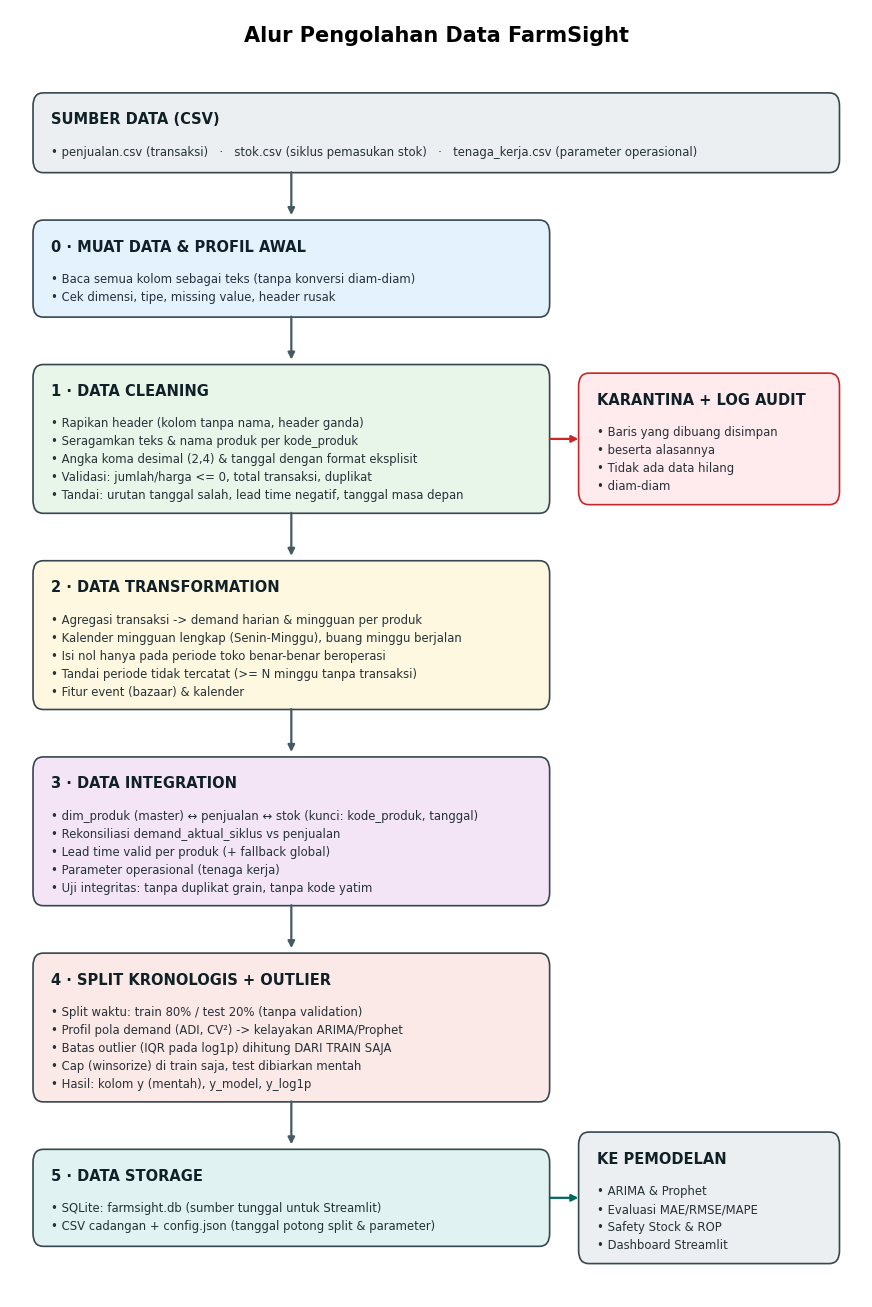

In [ ]:
def gambar_alur():
    tahap = [
        ('0 · MUAT DATA & PROFIL AWAL', ['Baca semua kolom sebagai teks (tanpa konversi diam-diam)',
                                          'Cek dimensi, tipe, missing value, header rusak'], '#E3F2FD'),
        ('1 · DATA CLEANING', ['Rapikan header (kolom tanpa nama, header ganda)',
                               'Seragamkan teks & nama produk per kode_produk',
                               'Angka koma desimal (2,4) & tanggal dengan format eksplisit',
                               'Validasi: jumlah/harga <= 0, total transaksi, duplikat',
                               'Tandai: urutan tanggal salah, lead time negatif, tanggal masa depan'], '#E8F5E9'),
        ('2 · DATA TRANSFORMATION', ['Agregasi transaksi -> demand harian & mingguan per produk',
                                     'Kalender mingguan lengkap (Senin-Minggu), buang minggu berjalan',
                                     'Isi nol hanya pada periode toko benar-benar beroperasi',
                                     'Tandai periode tidak tercatat (>= N minggu tanpa transaksi)',
                                     'Fitur event (bazaar) & kalender'], '#FFF8E1'),
        ('3 · DATA INTEGRATION', ['dim_produk (master) ↔ penjualan ↔ stok (kunci: kode_produk, tanggal)',
                                  'Rekonsiliasi demand_aktual_siklus vs penjualan',
                                  'Lead time valid per produk (+ fallback global)',
                                  'Parameter operasional (tenaga kerja)',
                                  'Uji integritas: tanpa duplikat grain, tanpa kode yatim'], '#F3E5F5'),
        ('4 · SPLIT KRONOLOGIS + OUTLIER', ['Split waktu: train 80% / test 20% (tanpa validation)',
                                            'Profil pola demand (ADI, CV²) -> kelayakan ARIMA/Prophet',
                                            'Batas outlier (IQR pada log1p) dihitung DARI TRAIN SAJA',
                                            'Cap (winsorize) di train saja, test dibiarkan mentah',
                                            'Hasil: kolom y (mentah), y_model, y_log1p'], '#FBE9E7'),
        ('5 · DATA STORAGE', ['SQLite: farmsight.db (sumber tunggal untuk Streamlit)',
                              'CSV cadangan + config.json (tanggal potong split & parameter)'], '#E0F2F1'),
    ]
    tinggi = lambda n: 5.2 + 1.6 * n
    gap, margin = 5.0, 8.0
    h_sumber = tinggi(1)
    total = margin + h_sumber + gap + sum(tinggi(len(t[1])) + gap for t in tahap)
    fig, ax = plt.subplots(figsize=(11, total * 0.14))
    ax.set_xlim(0, 100); ax.set_ylim(0, total); ax.axis('off')

    def kotak(x, ytop, w, judul, isi, warna, ec='#37474F'):
        h = tinggi(len(isi))
        ax.add_patch(FancyBboxPatch((x, ytop - h), w, h, boxstyle='round,pad=0.3,rounding_size=1.2', fc=warna, ec=ec, lw=1.2))
        ax.text(x + 1.8, ytop - 1.5, judul, fontsize=10.5, fontweight='bold', va='top', color='#102027')
        ax.text(x + 1.8, ytop - 4.6, '\n'.join('• ' + t for t in isi), fontsize=8.4, va='top', color='#263238', linespacing=1.5)
        return ytop - h

    def panah(x1, y1, x2, y2, warna='#455A64'):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='-|>', color=warna, lw=1.6))

    ax.text(50, total - 1.5, 'Alur Pengolahan Data FarmSight', ha='center', va='top', fontsize=15, fontweight='bold')
    y = total - margin
    y_bawah = kotak(3, y, 94, 'SUMBER DATA (CSV)', ['penjualan.csv (transaksi)   ·   stok.csv (siklus pemasukan stok)   ·   tenaga_kerja.csv (parameter operasional)'], '#ECEFF1')
    posisi = {}
    for judul, isi, warna in tahap:
        panah(33, y_bawah, 33, y_bawah - gap + 0.5)
        y = y_bawah - gap
        y_bawah = kotak(3, y, 60, judul, isi, warna)
        posisi[judul[:1]] = (y, y_bawah)
    # kotak samping
    yc_top, yc_bot = posisi['1']
    kotak(67, (yc_top + yc_bot) / 2 + tinggi(4) / 2, 30, 'KARANTINA + LOG AUDIT',
          ['Baris yang dibuang disimpan', 'beserta alasannya', 'Tidak ada data hilang', 'diam-diam'], '#FFEBEE', '#C62828')
    panah(63, (yc_top + yc_bot) / 2, 67, (yc_top + yc_bot) / 2, '#C62828')
    ys_top, ys_bot = posisi['5']
    kotak(67, (ys_top + ys_bot) / 2 + tinggi(4) / 2, 30, 'KE PEMODELAN',
          ['ARIMA & Prophet', 'Evaluasi MAE/RMSE/MAPE', 'Safety Stock & ROP', 'Dashboard Streamlit'], '#ECEFF1')
    panah(63, (ys_top + ys_bot) / 2, 67, (ys_top + ys_bot) / 2, '#00695C')
    return fig

fig = gambar_alur(); simpan_fig(fig, '00_alur_pengolahan_data.png'); plt.show()

## Tahap 0 — Muat data & profil awal
Semua kolom dibaca sebagai teks (`dtype=str`) supaya konversi angka/tanggal dilakukan sadar, bukan diam-diam oleh pandas.

**Kenapa tidak langsung biarkan pandas menebak tipe data?** Kalau `read_csv` dibiarkan menebak sendiri, angka
yang memakai koma desimal (`"2,4"`) atau kode produk yang kebetulan berupa angka bisa salah baca tanpa
pemberitahuan apa pun — errornya baru kelihatan jauh di belakang, saat model sudah dilatih dengan data yang
salah. Membaca semuanya sebagai teks dulu memaksa setiap konversi (ke angka, ke tanggal) dilakukan eksplisit
di Tahap 1, sehingga baris yang gagal dikonversi bisa ditangkap dan dicatat, bukan diam-diam berubah jadi `NaN`
atau salah nilai.

In [ ]:
raw_jual = pd.read_csv(PATH['penjualan'], dtype=str)
raw_stok = pd.read_csv(PATH['stok'], dtype=str)
raw_tk   = pd.read_csv(PATH['tenaga_kerja'], dtype=str)

def profil_kolom(df):
    return pd.DataFrame({'terisi': df.notna().sum(), 'kosong': df.isna().sum(), 'unik': df.nunique()})

print('PENJUALAN', raw_jual.shape); display(profil_kolom(raw_jual))
print('\nSTOK', raw_stok.shape);     display(profil_kolom(raw_stok))
print('\nTENAGA KERJA', raw_tk.shape); display(raw_tk)

PENJUALAN (723, 16)


,terisi,kosong,unik
no.,723,0,723
tanggal_pemesanan,723,0,379
tanggal_barang_keluar,723,0,355
Unnamed: 3,723,0,10
jenis_hari,723,0,3
nama_pembeli,723,0,65
kode_produk,723,0,38
nama_produk,723,0,41
kategori,723,0,4
jumlah_produk_dibeli,723,0,33



STOK (176, 8)


,terisi,kosong,unik
tanggal_pemesanantanggal_pemesanan,176,0,118
tanggal_barang_masuk,176,0,98
tanggal_barang_keluar,176,0,91
kode_produk,176,0,38
nama_produk,176,0,38
jumlah_produk_masuk,176,0,114
satuan_produk,176,0,10
demand_aktual_siklus,176,0,64



TENAGA KERJA (1, 1)


,tenaga_kerja
0,10


## Tahap 1 — Data Cleaning
Sesuai jurnal: pemeriksaan duplikat, missing value, format tidak sesuai, data tidak valid, dan
ketidakkonsistenan penulisan produk.

**Kenapa tahap ini wajib sebelum data dipakai?** Model forecasting tidak bisa membedakan "nol karena memang
tidak ada yang beli" dari "nol karena barisnya rusak/gagal dibaca" — keduanya akan diperlakukan sebagai
sinyal yang sama. Kalau data kotor (nama produk ganda, angka gagal konversi, duplikat) tidak dibereskan dulu,
kesalahan itu ikut terhitung sebagai demand mingguan dan mencemari baik pelatihan model maupun evaluasi
akurasinya nanti — dan karena polanya tersembunyi di balik agregasi, kesalahannya baru kelihatan setelah
semua tahap selesai, jauh lebih sulit dilacak sumbernya.

**Temuan pada data ini yang ditangani di sini:**
- Header kolom ke-4 pada `penjualan` kosong (terbaca `Unnamed: 3`). Isinya ternyata **selisih hari pesan → keluar** (diverifikasi otomatis di bawah), bukan noise.
- Header `stok` rusak: `tanggal_pemesanantanggal_pemesanan`.
- Angka memakai **koma desimal** (`2,4` kg pada Labu Prida). `pd.to_numeric(..., errors='coerce')` akan mengubahnya jadi NaN lalu barisnya terbuang.
- Nama produk tidak konsisten (`'KANGKUNG '`, `' KANGKUNG'`, `'SELADA '`, `ES TELANG` vs `TEH BUNGA TELANG` pada kode yang sama).

In [ ]:
def rapikan_kolom(cols):
    hasil = []
    for i, c in enumerate(cols):
        c = str(c).strip()
        if c == '' or c.lower().startswith('unnamed'):
            c = f'kolom_tanpa_nama_{i}'
        m = re.fullmatch(r'(.+?)\1', c)              # header ganda: 'abcabc' -> 'abc'
        if m:
            c = m.group(1)
        hasil.append(re.sub(r'[^0-9a-zA-Z]+', '_', c).strip('_').lower())
    return hasil

def rapikan_teks(s, kapital=True):
    s = s.astype('string').str.strip().str.replace(r'\s+', ' ', regex=True)
    return s.str.upper() if kapital else s.str.lower()

def ke_angka(s):
    """Konversi teks -> float. Mendukung koma desimal ('2,4'). Mengembalikan (hasil, n_koma, n_gagal)."""
    x = s.astype('string').str.strip()
    n_koma = int(x.str.fullmatch(r'-?\d+,\d+').fillna(False).sum())
    hasil = pd.to_numeric(x.str.replace(',', '.', regex=False), errors='coerce').astype(float)
    n_gagal = int((hasil.isna() & s.notna()).sum())
    return hasil, n_koma, n_gagal

def ke_tanggal(s):
    hasil = pd.to_datetime(s.astype('string').str.strip(), format=FORMAT_TANGGAL, errors='coerce')
    return hasil, int((hasil.isna() & s.notna()).sum())

def terapkan_aturan(df, mask, sumber, aturan):
    n = int(mask.sum())
    catat(sumber, 'cleaning', aturan, n, 'dikarantina (dibuang)')
    if n:
        karantina(df[mask], sumber, aturan)
    return df[~mask].copy()

JENIS_HARI = {'REGULER': 'REGULER', 'BAZZAR': 'BAZAAR', 'BAZAAR': 'BAZAAR',
              'MINI BAZZAR': 'MINI BAZAAR', 'MINI BAZAAR': 'MINI BAZAAR'}

def nama_baku_per_kode(df):
    """Nama paling sering muncul per kode (jika seri, ambil yang lebih panjang)."""
    peta = {}
    for kode, g in df.groupby('kode_produk'):
        vc = g['nama_produk'].value_counts()
        peta[kode] = sorted(vc.items(), key=lambda kv: (-kv[1], -len(kv[0])))[0][0]
    return peta

### 1a. Cleaning data penjualan
**Kenapa penjualan dibersihkan terpisah dari stok?** Sumber errornya beda: penjualan rawan salah ketik nama
produk & format angka koma, sedangkan stok rawan header rusak & satuan tidak konsisten. Menyatukan
keduanya dalam satu fungsi pembersihan akan membuat aturan validasi salah satu sisi ikut diterapkan
secara keliru ke sisi yang lain.

In [ ]:
def bersihkan_penjualan(raw):
    S = 'penjualan'
    df = raw.copy()
    kolom_asli = list(df.columns)
    df.columns = rapikan_kolom(df.columns)
    n_hdr = sum(1 for a, b in zip(kolom_asli, df.columns) if a.lower().startswith('unnamed') or a.strip() == '')
    catat(S, 'cleaning', 'header kolom kosong (Unnamed) -> dinamai selisih_hari_csv', n_hdr, 'diperbaiki')
    df = df.rename(columns={c: 'selisih_hari_csv' for c in df.columns if c.startswith('kolom_tanpa_nama')})
    df = df.rename(columns={'no': 'no_asal'})
    df['no_asal'] = pd.to_numeric(df['no_asal'], errors='coerce')
    n0 = len(df)

    # baris kosong total
    df = terapkan_aturan(df, df.drop(columns=['no_asal']).isna().all(axis=1), S, 'baris kosong total')

    # penyeragaman teks
    sebelum = df.copy()
    for c in ['kode_produk', 'nama_produk', 'nama_pembeli', 'satuan_produk', 'jenis_hari']:
        df[c] = rapikan_teks(df[c])
    df['kategori'] = rapikan_teks(df['kategori'], kapital=False)
    df['jenis_hari'] = df['jenis_hari'].map(JENIS_HARI).fillna(df['jenis_hari'])
    berubah = int((sebelum['nama_produk'].fillna('') != df['nama_produk'].fillna('')).sum())
    catat(S, 'cleaning', 'spasi berlebih / huruf besar-kecil pada nama produk', berubah, 'diperbaiki')

    # nama baku per kode_produk (kode = kunci utama produk)
    peta = nama_baku_per_kode(df)
    beda = (df['nama_produk'] != df['kode_produk'].map(peta)).fillna(False).astype(bool)
    catat(S, 'cleaning', 'nama beda pada kode sama -> nama baku', beda.sum(), 'diperbaiki',
          '; '.join(sorted(set(f"{k}: {v}" for k, v in zip(df.loc[beda, 'kode_produk'], df.loc[beda, 'nama_produk'])))))
    df['nama_produk'] = df['kode_produk'].map(peta)

    # angka (koma desimal) & tanggal (format eksplisit)
    for c in ['jumlah_produk_dibeli', 'harga_satuan', 'ukuran_harga', 'diskon', 'total_transaksi', 'selisih_hari_csv']:
        df[c], n_koma, n_gagal = ke_angka(df[c])
        if n_koma and c != 'selisih_hari_csv': catat(S, 'cleaning', f'koma desimal pada {c}', n_koma, 'diperbaiki (koma -> titik)')
        if n_gagal: catat(S, 'cleaning', f'{c} tidak bisa dibaca sebagai angka', n_gagal, 'jadi NaN')
    for c in ['tanggal_pemesanan', 'tanggal_barang_keluar']:
        df[c], n_gagal = ke_tanggal(df[c])
        if n_gagal: catat(S, 'cleaning', f'{c} format tanggal tidak valid', n_gagal, 'jadi NaT')

    # aturan validitas (baris dibuang -> karantina)
    df = terapkan_aturan(df, df[['kode_produk', 'tanggal_barang_keluar', 'jumlah_produk_dibeli']].isna().any(axis=1),
                         S, 'kolom kunci kosong (kode/tanggal keluar/jumlah)')
    df = terapkan_aturan(df, df['jumlah_produk_dibeli'] <= 0, S, 'jumlah_produk_dibeli <= 0')
    df = terapkan_aturan(df, df['harga_satuan'].fillna(0) <= 0, S, 'harga_satuan kosong / <= 0')
    kolom_dup = [c for c in df.columns if c != 'no_asal']
    df = terapkan_aturan(df, df.duplicated(subset=kolom_dup, keep='first'), S, 'duplikat persis (semua kolom, kecuali nomor baris)')

    # penandaan (baris dipertahankan, diberi flag)
    df['selisih_hari'] = (df['tanggal_barang_keluar'] - df['tanggal_pemesanan']).dt.days
    cocok = (df['selisih_hari'] == df['selisih_hari_csv']).sum()
    catat(S, 'cleaning', 'verifikasi kolom tanpa nama = selisih hari pesan->keluar', 0, 'terverifikasi',
          f'cocok {int(cocok)} dari {len(df)} baris')
    df['flag_urutan_tanggal_salah'] = df['selisih_hari'] < 0
    catat(S, 'cleaning', 'tanggal keluar < tanggal pemesanan', df['flag_urutan_tanggal_salah'].sum(),
          'ditandai; selisih_hari dikosongkan')
    df.loc[df['flag_urutan_tanggal_salah'], 'selisih_hari'] = np.nan
    df = df.drop(columns=['selisih_hari_csv'])

    hit = df['jumlah_produk_dibeli'] * df['harga_satuan'] - df['diskon']
    df['flag_total_tidak_cocok'] = (hit - df['total_transaksi']).abs() > TOL_RUPIAH
    catat(S, 'cleaning', 'total_transaksi != jumlah x harga - diskon', df['flag_total_tidak_cocok'].sum(), 'ditandai')

    df['flag_tgl_masa_depan'] = df['tanggal_barang_keluar'] > TANGGAL_MAKS
    catat(S, 'cleaning', f'tanggal barang keluar setelah {TANGGAL_MAKS.date()} (masa depan)',
          df['flag_tgl_masa_depan'].sum(),
          'dikeluarkan dari pemodelan' if BUANG_TANGGAL_MASA_DEPAN else 'ditandai',
          'periksa: salah ketik tahun/bulan, atau pesanan terjadwal?')
    if BUANG_TANGGAL_MASA_DEPAN:
        karantina(df[df['flag_tgl_masa_depan']], S, 'tanggal masa depan')

    df['is_bazaar'] = (df['jenis_hari'] == 'BAZAAR').astype(int)
    df['is_mini_bazaar'] = (df['jenis_hari'] == 'MINI BAZAAR').astype(int)
    catat(S, 'cleaning', 'ringkasan', 0, 'selesai', f'{n0} baris awal -> {len(df)} baris lolos validitas')
    return df.sort_values(['tanggal_barang_keluar', 'no_asal']).reset_index(drop=True), peta

jual, PETA_NAMA = bersihkan_penjualan(raw_jual)
print('\nKolom hasil:', list(jual.columns))
display(jual.head(3))

  [penjualan] header kolom kosong (Unnamed) -> dinamai selisih_hari_csv: 1 baris -> diperbaiki
  [penjualan] spasi berlebih / huruf besar-kecil pada nama produk: 6 baris -> diperbaiki
  [penjualan] nama beda pada kode sama -> nama baku: 1 baris -> diperbaiki
  [penjualan] koma desimal pada jumlah_produk_dibeli: 5 baris -> diperbaiki (koma -> titik)
  [penjualan] tanggal keluar < tanggal pemesanan: 1 baris -> ditandai; selisih_hari dikosongkan
  [penjualan] tanggal barang keluar setelah 2026-10-02 (masa depan): 28 baris -> dikeluarkan dari pemodelan

Kolom hasil: ['no_asal', 'tanggal_pemesanan', 'tanggal_barang_keluar', 'jenis_hari', 'nama_pembeli', 'kode_produk', 'nama_produk', 'kategori', 'jumlah_produk_dibeli', 'harga_satuan', 'ukuran_harga', 'satuan_produk', 'diskon', 'total_transaksi', 'keterangan', 'selisih_hari', 'flag_urutan_tanggal_salah', 'flag_total_tidak_cocok', 'flag_tgl_masa_depan', 'is_bazaar', 'is_mini_bazaar']


,no_asal,tanggal_pemesanan,tanggal_barang_keluar,jenis_hari,nama_pembeli,kode_produk,nama_produk,kategori,jumlah_produk_dibeli,harga_satuan,ukuran_harga,satuan_produk,diskon,total_transaksi,keterangan,selisih_hari,flag_urutan_tanggal_salah,flag_total_tidak_cocok,flag_tgl_masa_depan,is_bazaar,is_mini_bazaar
0,1,2023-12-25,2024-01-01,REGULER,BU IRRIS,PLB,PERMEN LIDAH BUAYA,makanan,2.0,10000.0,100.0,GR,0.0,20000.0,2 PCS PERMEN LIDAH BUAYA,7.0,False,False,False,0,0
1,2,2023-12-31,2024-01-01,REGULER,DAWIS,PLB,PERMEN LIDAH BUAYA,makanan,2.0,10000.0,100.0,GR,0.0,20000.0,2 PCS PERMEN LIDAH BUAYA,1.0,False,False,False,0,0
2,3,2024-01-02,2024-01-02,REGULER,ANILA,SAW,SAWI,sayuran,5.0,4000.0,1.0,IKAT,0.0,20000.0,"SAWI, SELADA, KANGKUNG",0.0,False,False,False,0,0


### 1b. Cleaning data stok
**Kenapa perlu direkonsiliasi dengan penjualan (bukan cuma dibersihkan sendiri)?** Data stok dipakai nanti
untuk menghitung Safety Stock/ROP, jadi kalau ada baris stok yang kode produknya tidak match dengan master
produk di penjualan, angka safety stock yang dihasilkan bisa merujuk ke produk yang salah tanpa ada error
yang muncul di kode.

In [ ]:
def bersihkan_stok(raw, peta_nama):
    S = 'stok'
    df = raw.copy()
    kolom_asli = list(df.columns)
    df.columns = rapikan_kolom(df.columns)      # memperbaiki header ganda 'tanggal_pemesanantanggal_pemesanan'
    catat(S, 'cleaning', 'header ganda (mis. tanggal_pemesanantanggal_pemesanan)', sum(a != b for a, b in zip(kolom_asli, df.columns)), 'diperbaiki')
    n0 = len(df)
    df = terapkan_aturan(df, df.isna().all(axis=1), S, 'baris kosong total')

    for c in ['kode_produk', 'nama_produk', 'satuan_produk']:
        df[c] = rapikan_teks(df[c])
    kode_asing = ~df['kode_produk'].isin(peta_nama.keys())
    catat(S, 'cleaning', 'kode_produk tidak ada di data penjualan', kode_asing.sum(), 'ditandai')
    df['nama_produk'] = df['kode_produk'].map(peta_nama).fillna(df['nama_produk'])

    for c in ['jumlah_produk_masuk', 'demand_aktual_siklus']:
        df[c], n_koma, n_gagal = ke_angka(df[c])
        if n_gagal: catat(S, 'cleaning', f'{c} tidak bisa dibaca sebagai angka', n_gagal, 'jadi NaN')
    for c in ['tanggal_pemesanan', 'tanggal_barang_masuk', 'tanggal_barang_keluar']:
        df[c], n_gagal = ke_tanggal(df[c])
        if n_gagal: catat(S, 'cleaning', f'{c} format tanggal tidak valid', n_gagal, 'jadi NaT')

    df = terapkan_aturan(df, df[['kode_produk', 'tanggal_barang_keluar', 'jumlah_produk_masuk']].isna().any(axis=1),
                         S, 'kolom kunci kosong')
    df = terapkan_aturan(df, df['jumlah_produk_masuk'] <= 0, S, 'jumlah_produk_masuk <= 0')
    df = terapkan_aturan(df, df['demand_aktual_siklus'] < 0, S, 'demand_aktual_siklus negatif')
    df = terapkan_aturan(df, df.duplicated(keep='first'), S, 'duplikat persis')
    df = terapkan_aturan(df, df.duplicated(subset=['kode_produk', 'tanggal_barang_keluar'], keep='first'),
                         S, 'batch ganda (kode_produk + tanggal keluar sama)')

    df['flag_demand_melebihi_masuk'] = df['demand_aktual_siklus'] > df['jumlah_produk_masuk']
    catat(S, 'cleaning', 'demand siklus > jumlah masuk', df['flag_demand_melebihi_masuk'].sum(), 'ditandai')
    df['flag_urutan_masuk_keluar_salah'] = df['tanggal_barang_keluar'] < df['tanggal_barang_masuk']
    catat(S, 'cleaning', 'tanggal keluar < tanggal masuk', df['flag_urutan_masuk_keluar_salah'].sum(), 'ditandai')
    df['lt_pemasok_hari'] = (df['tanggal_barang_masuk'] - df['tanggal_pemesanan']).dt.days
    df['flag_lt_pemasok_negatif'] = df['lt_pemasok_hari'] < 0
    catat(S, 'cleaning', 'barang masuk SEBELUM tanggal pemesanan (lead time negatif)', df['flag_lt_pemasok_negatif'].sum(),
          'ditandai; dikecualikan dari perhitungan lead time',
          'kemungkinan tanggal_pemesanan di stok bermakna lain (mis. tanggal pesanan pelanggan) - perlu konfirmasi')
    df['rasio_pemakaian'] = df['demand_aktual_siklus'] / df['jumlah_produk_masuk']
    df['flag_overstock_ekstrem'] = df['rasio_pemakaian'] < 0.10
    catat(S, 'cleaning', 'stok terpakai < 10% dari yang masuk', df['flag_overstock_ekstrem'].sum(), 'ditandai',
          'bisa overstock nyata atau salah ketik jumlah masuk')
    tgl_maks = df[['tanggal_pemesanan', 'tanggal_barang_masuk', 'tanggal_barang_keluar']].max(axis=1)
    df['flag_tgl_masa_depan'] = tgl_maks > TANGGAL_MAKS
    catat(S, 'cleaning', f'tanggal setelah {TANGGAL_MAKS.date()} (masa depan)', df['flag_tgl_masa_depan'].sum(),
          'dikeluarkan dari pemodelan' if BUANG_TANGGAL_MASA_DEPAN else 'ditandai')
    if BUANG_TANGGAL_MASA_DEPAN:
        karantina(df[df['flag_tgl_masa_depan']], S, 'tanggal masa depan')
    catat(S, 'cleaning', 'ringkasan', 0, 'selesai', f'{n0} baris awal -> {len(df)} baris lolos validitas')
    return df.sort_values(['kode_produk', 'tanggal_barang_keluar']).reset_index(drop=True)

stok = bersihkan_stok(raw_stok, PETA_NAMA)
display(stok.head(3))

  [stok] header ganda (mis. tanggal_pemesanantanggal_pemesanan): 1 baris -> diperbaiki
  [stok] batch ganda (kode_produk + tanggal keluar sama): 40 baris -> dikarantina (dibuang)
  [stok] barang masuk SEBELUM tanggal pemesanan (lead time negatif): 76 baris -> ditandai; dikecualikan dari perhitungan lead time
  [stok] stok terpakai < 10% dari yang masuk: 31 baris -> ditandai
  [stok] tanggal setelah 2026-10-02 (masa depan): 2 baris -> dikeluarkan dari pemodelan


,tanggal_pemesanan,tanggal_barang_masuk,tanggal_barang_keluar,kode_produk,nama_produk,jumlah_produk_masuk,satuan_produk,demand_aktual_siklus,flag_demand_melebihi_masuk,flag_urutan_masuk_keluar_salah,lt_pemasok_hari,flag_lt_pemasok_negatif,rasio_pemakaian,flag_overstock_ekstrem,flag_tgl_masa_depan
0,2024-01-25,2024-01-24,2024-01-25,BLB,BIBIT LIDAH BUAYA,58.0,BIBIT,48.0,False,False,-1,True,0.827586,False,False
1,2024-07-31,2024-08-02,2024-08-03,BLB,BIBIT LIDAH BUAYA,27.0,BIBIT,2.0,False,False,2,False,0.074074,True,False
2,2025-09-23,2025-09-25,2025-09-26,BLB,BIBIT LIDAH BUAYA,24.0,BIBIT,3.0,False,False,2,False,0.125000,False,False


### 1c. Parameter tenaga kerja
**Kenapa data ini perlu dibersihkan juga meski kecil?** Dipakai sebagai konteks operasional (kapasitas
proses/pemenuhan pesanan) di dashboard, bukan untuk forecasting demand — tapi kalau nilainya salah baca
(mis. karena format angka koma yang sama seperti di penjualan), rekomendasi kapasitas yang ditampilkan ke
pengguna dashboard ikut salah tanpa terlihat jelas dari mana errornya.

In [ ]:
tk_val, _, tk_gagal = ke_angka(raw_tk.iloc[:, 0])
if tk_gagal or tk_val.isna().all() or (tk_val.dropna() <= 0).any():
    raise ValueError('File tenaga_kerja harus berisi angka > 0')
TENAGA_KERJA = int(tk_val.dropna().iloc[0])
catat('tenaga_kerja', 'cleaning', 'validasi', 0, 'ok', f'jumlah tenaga kerja = {TENAGA_KERJA}')
print('Tenaga kerja:', TENAGA_KERJA)

Tenaga kerja: 10


### Diagram hasil cleaning — baris yang diperbaiki / ditandai / dikarantina

**Kenapa ditampilkan?** Supaya keputusan pembersihan bisa diaudit — berapa baris yang terdampak dan jenis masalahnya apa — bukan hanya "data sudah dibersihkan" tanpa bukti.

Diagram tersimpan: /content/farmsight_output/diagram/01_ringkasan_cleaning.png


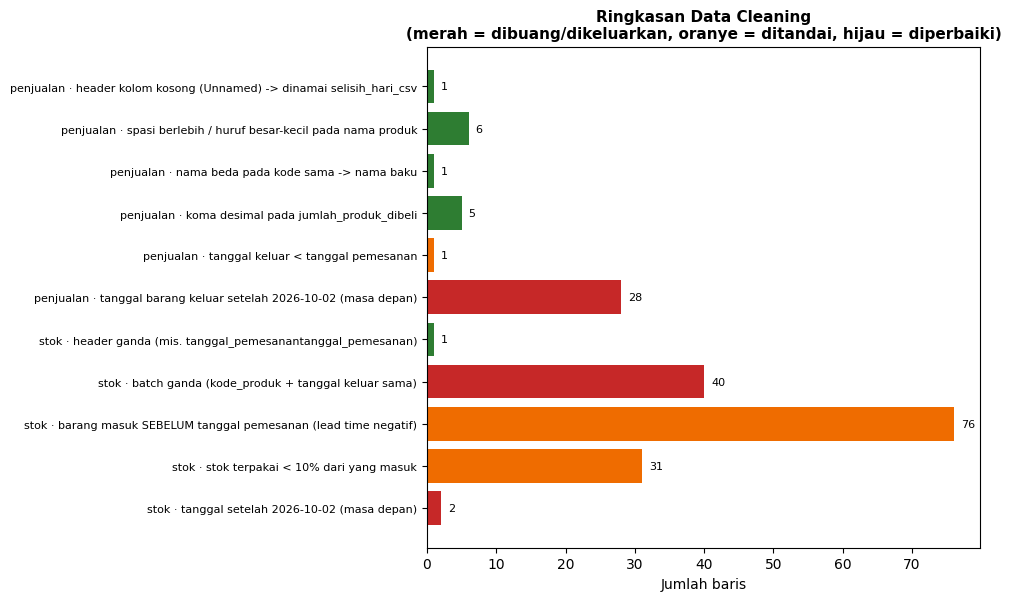

In [ ]:
log_df = pd.DataFrame(LOG)
tampil = log_df[(log_df['jumlah_baris'] > 0)].copy()
tampil['label'] = tampil['sumber'] + ' · ' + tampil['aturan'].str.slice(0, 70)
warna = tampil['tindakan'].map(lambda t: '#C62828' if 'karantina' in t or 'dikeluarkan' in t
                               else ('#EF6C00' if 'ditandai' in t else '#2E7D32'))
fig, ax = plt.subplots(figsize=(10, 0.42 * len(tampil) + 1.5))
ax.barh(tampil['label'][::-1], tampil['jumlah_baris'][::-1], color=list(warna[::-1]))
for i, v in enumerate(tampil['jumlah_baris'][::-1]):
    ax.text(v + 1, i, str(v), va='center', fontsize=8)
ax.set_xlabel('Jumlah baris')
ax.set_title('Ringkasan Data Cleaning\n(merah = dibuang/dikeluarkan, oranye = ditandai, hijau = diperbaiki)', fontsize=11, fontweight='bold')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout(); simpan_fig(fig, '01_ringkasan_cleaning.png'); plt.show()

## Tahap 2 — Data Transformation
Sesuai jurnal: penyesuaian format tanggal, agregasi transaksi, pengelompokan per produk dan periode.
Data penjualan diubah menjadi **data permintaan (demand)** per produk per periode.

**Keputusan penting: granularitas mingguan.** Data ini sangat *sparse*: hanya sekitar sepertiga hari yang punya transaksi,
dan tiap produk hanya terjual di sebagian kecil hari. Deret harian didominasi angka nol (*intermittent demand*), yang
membuat ARIMA/Prophet cenderung menebak nol atau rata-rata. Agregasi mingguan mengurangi noise ini secara signifikan
(lihat perbandingan rasio nol di bawah). Tabel harian tetap disimpan untuk drill-down di dashboard.

**Tiga aturan agar deret waktu jujur:**
1. Minggu berjalan yang belum lengkap dibuang (kalau tidak, demand terbaca rendah).
2. Nol hanya diisi pada minggu toko *beroperasi*. Rentang ≥ `MIN_GAP_MINGGU` minggu tanpa satu pun transaksi
   dianggap **tidak tercatat** dan diisi `NaN`, bukan nol — kalau tidak, model belajar bahwa permintaan "runtuh" padahal datanya memang tidak ada.
3. Sebelum produk pertama kali terjual, nilainya `NaN` (produk belum ada), bukan nol.

In [ ]:
jual_pakai = jual[~jual['flag_tgl_masa_depan']].copy() if BUANG_TANGGAL_MASA_DEPAN else jual.copy()
stok_pakai = stok[~stok['flag_tgl_masa_depan']].copy() if BUANG_TANGGAL_MASA_DEPAN else stok.copy()
print(f'Penjualan dipakai: {len(jual_pakai)} baris | Stok dipakai: {len(stok_pakai)} baris')

jual_pakai['tanggal'] = jual_pakai['tanggal_barang_keluar']
jual_pakai['minggu_mulai'] = jual_pakai['tanggal'].dt.to_period('W-SUN').dt.start_time   # Senin

# ---- (a) Demand harian (hanya hari yang ada transaksi, untuk drill-down dashboard) ----
demand_harian = (jual_pakai.groupby(['kode_produk', 'tanggal'])
                 .agg(demand=('jumlah_produk_dibeli', 'sum'), pendapatan=('total_transaksi', 'sum'),
                      n_transaksi=('jumlah_produk_dibeli', 'size'),
                      ada_bazaar=('is_bazaar', 'max'), ada_mini_bazaar=('is_mini_bazaar', 'max'))
                 .reset_index())

# ---- (b) Kalender mingguan lengkap ----
minggu_lengkap_terakhir = (TANGGAL_MAKS - pd.Timedelta(days=6)).to_period('W-SUN').start_time
awal_minggu = jual_pakai['minggu_mulai'].min()
akhir_minggu = min(minggu_lengkap_terakhir, jual_pakai['minggu_mulai'].max())
kalender = pd.DataFrame({'minggu_mulai': pd.date_range(awal_minggu, akhir_minggu, freq='7D')})

per_minggu_toko = (jual_pakai.groupby('minggu_mulai')
                   .agg(n_transaksi_toko=('jumlah_produk_dibeli', 'size'),
                        ada_bazaar=('is_bazaar', 'max'), ada_mini_bazaar=('is_mini_bazaar', 'max'))
                   .reset_index())
kalender = kalender.merge(per_minggu_toko, on='minggu_mulai', how='left')
for c in ['n_transaksi_toko', 'ada_bazaar', 'ada_mini_bazaar']:
    kalender[c] = kalender[c].fillna(0).astype(int)

# ---- (c) Deteksi periode tidak tercatat (rentang panjang tanpa satu pun transaksi) ----
aktif = kalender['n_transaksi_toko'] > 0
id_run = (aktif != aktif.shift()).cumsum()
panjang_run = aktif.groupby(id_run).transform('size')
kalender['tidak_tercatat'] = (~aktif) & (panjang_run >= MIN_GAP_MINGGU)
kalender['di_luar_rentang'] = (kalender['minggu_mulai'] < pd.Timestamp(TANGGAL_MULAI_DATA)) if TANGGAL_MULAI_DATA else False
kalender['tahun'] = kalender['minggu_mulai'].dt.year
kalender['kuartal'] = kalender['minggu_mulai'].dt.quarter
kalender['bulan'] = kalender['minggu_mulai'].dt.month
kalender['minggu_ke'] = kalender['minggu_mulai'].dt.isocalendar().week.astype(int)

gap = kalender[kalender['tidak_tercatat']]
print(f'Kalender: {len(kalender)} minggu ({awal_minggu.date()} s/d {akhir_minggu.date()})')
print(f'Minggu tanpa transaksi sama sekali: {(~aktif).sum()} | dari itu dianggap TIDAK TERCATAT (>= {MIN_GAP_MINGGU} minggu berturut-turut): {len(gap)}')
if len(gap):
    g = gap.assign(blok=(gap['minggu_mulai'].diff().dt.days != 7).cumsum())
    display(g.groupby('blok')['minggu_mulai'].agg(mulai='min', selesai='max', n_minggu='size'))

# ---- (d) Demand mingguan per produk (grid lengkap produk x minggu) ----
agg_minggu = (jual_pakai[jual_pakai['minggu_mulai'] <= akhir_minggu]
              .groupby(['kode_produk', 'minggu_mulai'])
              .agg(y=('jumlah_produk_dibeli', 'sum'), pendapatan=('total_transaksi', 'sum'),
                   n_transaksi=('jumlah_produk_dibeli', 'size'), n_hari_jual=('tanggal', 'nunique'))
              .reset_index())
produk = sorted(jual_pakai['kode_produk'].unique())
grid = pd.MultiIndex.from_product([produk, kalender['minggu_mulai']], names=['kode_produk', 'minggu_mulai']).to_frame(index=False)
mingguan = grid.merge(agg_minggu, on=['kode_produk', 'minggu_mulai'], how='left')
mingguan = mingguan.merge(kalender[['minggu_mulai', 'tidak_tercatat', 'di_luar_rentang', 'ada_bazaar', 'ada_mini_bazaar',
                                    'tahun', 'kuartal', 'bulan', 'minggu_ke']], on='minggu_mulai', how='left')
for c in ['y', 'pendapatan', 'n_transaksi', 'n_hari_jual']:
    mingguan[c] = mingguan[c].fillna(0)

minggu_pertama = agg_minggu.groupby('kode_produk')['minggu_mulai'].min()
mingguan['sebelum_produk_dijual'] = mingguan['minggu_mulai'] < mingguan['kode_produk'].map(minggu_pertama)
mingguan['status_periode'] = np.select(
    [mingguan['di_luar_rentang'], mingguan['tidak_tercatat'], mingguan['sebelum_produk_dijual']],
    ['di_luar_rentang', 'tidak_tercatat', 'sebelum_produk_dijual'], default='operasional')
mingguan = mingguan.drop(columns=['tidak_tercatat', 'di_luar_rentang', 'sebelum_produk_dijual'])
nonaktif = mingguan['status_periode'] != 'operasional'
mingguan.loc[nonaktif, ['y', 'pendapatan', 'n_transaksi', 'n_hari_jual']] = np.nan
mingguan = mingguan.sort_values(['kode_produk', 'minggu_mulai']).reset_index(drop=True)

# ---- perbandingan noise: harian vs mingguan (hanya periode operasional, setelah produk mulai dijual) ----
op = mingguan[mingguan['status_periode'] == 'operasional']
rasio_nol_minggu = (op['y'] == 0).mean()
dh = demand_harian.assign(minggu_mulai=demand_harian['tanggal'].dt.to_period('W-SUN').dt.start_time)
dh = dh.merge(mingguan[['kode_produk', 'minggu_mulai', 'status_periode']], on=['kode_produk', 'minggu_mulai'])
n_sel_hari = len(op) * 7
n_sel_hari_ada = int((dh['status_periode'] == 'operasional').sum())
rasio_nol_hari = 1 - n_sel_hari_ada / n_sel_hari
print(f'\nRasio nol pada deret per produk: harian = {rasio_nol_hari:.1%}  vs  mingguan = {rasio_nol_minggu:.1%}')
print(f'Ukuran tabel: demand_harian {demand_harian.shape}, mingguan (grid) {mingguan.shape}')
display(mingguan['status_periode'].value_counts().to_frame('jumlah_baris'))

Penjualan dipakai: 695 baris | Stok dipakai: 134 baris
Kalender: 143 minggu (2024-01-01 s/d 2026-09-21)
Minggu tanpa transaksi sama sekali: 42 | dari itu dianggap TIDAK TERCATAT (>= 4 minggu berturut-turut): 20


,mulai,selesai,n_minggu
blok,,,
1,2024-10-21,2025-01-20,14
2,2025-03-03,2025-04-07,6



Rasio nol pada deret per produk: harian = 97.9%  vs  mingguan = 88.9%
Ukuran tabel: demand_harian (584, 7), mingguan (grid) (5434, 13)


,jumlah_baris
status_periode,
operasional,3950
tidak_tercatat,760
sebelum_produk_dijual,724


## Tahap 3 — Data Integration
Sesuai jurnal: data produk diintegrasikan dengan data penjualan dan data persediaan.

**Catatan penting tentang `demand_aktual_siklus`.** Kolom ini di file stok ternyata adalah **jumlah penjualan sejak batch stok tersebut
keluar sampai batch berikutnya untuk produk yang sama** (diverifikasi oleh sel rekonsiliasi di bawah). Artinya kolom ini
turunan dari penjualan, bukan informasi independen. Karena itu:
- **tidak boleh** dipakai sebagai fitur untuk memprediksi demand (target bocor ke fitur),
- tetap berguna sebagai data *per siklus* untuk Safety Stock / ROP dan untuk validasi konsistensi data.

In [ ]:
# ---- (a) Master produk ----
def modus(s):
    m = s.dropna().mode()
    return m.iloc[0] if len(m) else np.nan

dim_produk = (jual_pakai.groupby('kode_produk')
              .agg(kategori=('kategori', modus), satuan_produk=('satuan_produk', modus),
                   ukuran_harga=('ukuran_harga', modus), harga_satuan=('harga_satuan', modus),
                   tanggal_pertama_jual=('tanggal', 'min'), tanggal_terakhir_jual=('tanggal', 'max'),
                   n_transaksi=('tanggal', 'size'), total_demand=('jumlah_produk_dibeli', 'sum'))
              .reset_index())
dim_produk.insert(1, 'nama_produk', dim_produk['kode_produk'].map(PETA_NAMA))
satuan_stok = stok_pakai.groupby('kode_produk')['satuan_produk'].agg(modus)
dim_produk['satuan_stok'] = dim_produk['kode_produk'].map(satuan_stok)
dim_produk['n_batch_stok'] = dim_produk['kode_produk'].map(stok_pakai.groupby('kode_produk').size()).fillna(0).astype(int)
minggu_terakhir_jual = dim_produk['tanggal_terakhir_jual'].dt.to_period('W-SUN').dt.start_time
dim_produk['minggu_sejak_terakhir_jual'] = ((akhir_minggu - minggu_terakhir_jual).dt.days // 7).clip(lower=0)
dim_produk['status_produk'] = np.where(dim_produk['minggu_sejak_terakhir_jual'] <= MAKS_MINGGU_TIDAK_AKTIF, 'aktif', 'tidak_aktif_terbaru')
n_nonaktif = int((dim_produk['status_produk'] != 'aktif').sum())
catat('integrasi', 'integration', f'produk tidak terjual > {MAKS_MINGGU_TIDAK_AKTIF} minggu terakhir', n_nonaktif, 'ditandai',
      'apakah produk dihentikan? jika ya, jangan diprediksi')
tak_cocok = dim_produk[dim_produk['satuan_stok'].notna() & (dim_produk['satuan_stok'] != dim_produk['satuan_produk'])]
catat('integrasi', 'integration', 'satuan penjualan != satuan stok', len(tak_cocok), 'ditandai')
print('Produk:', len(dim_produk))

# ---- (b) Rekonsiliasi demand_aktual_siklus vs penjualan ----
# Definisi siklus: dari tanggal_barang_keluar batch ini sampai sebelum tanggal_barang_keluar batch berikutnya (produk sama)
def hitung_siklus(stok_df, jual_df):
    hasil = []
    for kode, g in stok_df.sort_values(['kode_produk', 'tanggal_barang_keluar']).groupby('kode_produk'):
        s = jual_df[jual_df['kode_produk'] == kode]
        mulai = list(g['tanggal_barang_keluar'])
        akhir = mulai[1:] + [TGL_TAK_HINGGA]
        for (idx, _), t0, t1 in zip(g.iterrows(), mulai, akhir):
            m = (s['tanggal_barang_keluar'] >= t0) & (s['tanggal_barang_keluar'] < t1)
            hasil.append((idx, s.loc[m, 'jumlah_produk_dibeli'].sum(), t1))
    r = pd.DataFrame(hasil, columns=['idx', 'demand_siklus_hitung', 'tanggal_siklus_berakhir']).set_index('idx')
    return r

# memakai SEMUA baris yang lolos validitas (termasuk yang bertanggal masa depan) supaya siklus tidak terpotong
siklus_hit = hitung_siklus(stok, jual)
stok_rek = stok.join(siklus_hit)
stok_rek['selisih_siklus'] = stok_rek['demand_aktual_siklus'] - stok_rek['demand_siklus_hitung']
# selisih < 1 unit dianggap pembulatan (pada file stok, demand siklus produk berdesimal seperti Labu Prida 2,1 kg dibulatkan ke bilangan bulat)
stok_rek['flag_siklus_tidak_cocok'] = stok_rek['selisih_siklus'].abs() >= 1.0
n_cocok = int((~stok_rek['flag_siklus_tidak_cocok']).sum())
catat('integrasi', 'integration', 'demand_aktual_siklus != jumlah penjualan dalam siklus', stok_rek['flag_siklus_tidak_cocok'].sum(),
      'ditandai', f'cocok {n_cocok} dari {len(stok_rek)} batch')
print(f'Rekonsiliasi: {n_cocok} dari {len(stok_rek)} batch cocok persis dengan penjualan.')
if stok_rek['flag_siklus_tidak_cocok'].any():
    display(stok_rek.loc[stok_rek['flag_siklus_tidak_cocok'],
            ['kode_produk', 'tanggal_barang_keluar', 'jumlah_produk_masuk', 'demand_aktual_siklus', 'demand_siklus_hitung', 'selisih_siklus']])

fact_siklus_stok = stok_rek[~stok_rek['flag_tgl_masa_depan']].copy() if BUANG_TANGGAL_MASA_DEPAN else stok_rek.copy()
fact_siklus_stok['sisa_stok'] = fact_siklus_stok['jumlah_produk_masuk'] - fact_siklus_stok['demand_aktual_siklus']
fact_siklus_stok['durasi_siklus_hari'] = (fact_siklus_stok['tanggal_siklus_berakhir'].where(
    fact_siklus_stok['tanggal_siklus_berakhir'] < TGL_TAK_HINGGA) - fact_siklus_stok['tanggal_barang_keluar']).dt.days

# ---- (c) Lead time per produk ----
# Yang valid: barang masuk pada/sesudah tanggal pemesanan. Nilai negatif dikecualikan (lihat catatan di tahap 1).
lt_valid = fact_siklus_stok[fact_siklus_stok['lt_pemasok_hari'] >= 0]
lt_global = float(lt_valid['lt_pemasok_hari'].median()) if len(lt_valid) else np.nan
lt_produk = lt_valid.groupby('kode_produk')['lt_pemasok_hari'].agg(n_lt_valid='size', lt_median='median', lt_maks='max')
lt_pesan_keluar = (jual_pakai.dropna(subset=['selisih_hari']).groupby('kode_produk')['selisih_hari']
                   .agg(lt_pesan_keluar_median='median'))
param_lead_time = (dim_produk[['kode_produk']].merge(lt_produk, on='kode_produk', how='left')
                   .merge(lt_pesan_keluar, on='kode_produk', how='left'))
param_lead_time['n_lt_valid'] = param_lead_time['n_lt_valid'].fillna(0).astype(int)
pakai_produk = param_lead_time['n_lt_valid'] >= 3
param_lead_time['lead_time_hari'] = np.where(pakai_produk, param_lead_time['lt_median'], lt_global)
param_lead_time['sumber_lead_time'] = np.where(pakai_produk, 'produk (>=3 observasi valid)', 'median global (data produk kurang)')
param_lead_time['lead_time_minggu'] = param_lead_time['lead_time_hari'] / 7
n_lt_neg = int(fact_siklus_stok['flag_lt_pemasok_negatif'].sum())
print(f'Lead time pemasok: {len(lt_valid)} observasi valid, {n_lt_neg} negatif dikecualikan. Median global = {lt_global} hari.')
print('PERLU KONFIRMASI: pastikan makna kolom tanggal_pemesanan di file stok sebelum memakai lead time ini untuk ROP.')

# ---- (d) Tabel terpadu mingguan: demand + event + stok masuk ----
stok_mingguan = (fact_siklus_stok.assign(minggu_mulai=fact_siklus_stok['tanggal_barang_keluar'].dt.to_period('W-SUN').dt.start_time)
                 .groupby(['kode_produk', 'minggu_mulai'])
                 .agg(stok_masuk=('jumlah_produk_masuk', 'sum'), n_batch_stok=('jumlah_produk_masuk', 'size')).reset_index())
fact_mingguan = mingguan.merge(stok_mingguan, on=['kode_produk', 'minggu_mulai'], how='left')
fact_mingguan.loc[fact_mingguan['status_periode'] == 'operasional', ['stok_masuk', 'n_batch_stok']] = \
    fact_mingguan.loc[fact_mingguan['status_periode'] == 'operasional', ['stok_masuk', 'n_batch_stok']].fillna(0)

param_operasional = pd.DataFrame([{'parameter': 'tenaga_kerja', 'nilai': TENAGA_KERJA, 'satuan': 'orang'},
                                  {'parameter': 'lead_time_global', 'nilai': lt_global, 'satuan': 'hari'}])

# ---- (e) Uji integritas ----
assert not fact_mingguan.duplicated(['kode_produk', 'minggu_mulai']).any(), 'grain (produk, minggu) duplikat'
assert set(fact_mingguan['kode_produk']) <= set(dim_produk['kode_produk']), 'ada kode produk yatim di tabel mingguan'
assert set(fact_siklus_stok['kode_produk']) <= set(dim_produk['kode_produk']), 'ada kode produk yatim di stok'
total_y = fact_mingguan['y'].sum()
total_j = jual_pakai.loc[jual_pakai['minggu_mulai'] <= akhir_minggu, 'jumlah_produk_dibeli'].sum()
assert abs(total_y - total_j) < 1e-6, 'total demand mingguan != total penjualan'
print(f'Uji integritas lolos. Total demand mingguan = total penjualan = {total_y:,.1f}')
catat('integrasi', 'integration', 'uji integritas (grain, kode yatim, rekonsiliasi total)', 0, 'lolos')

  [integrasi] produk tidak terjual > 26 minggu terakhir: 15 baris -> ditandai
Produk: 38
  [integrasi] demand_aktual_siklus != jumlah penjualan dalam siklus: 50 baris -> ditandai
Rekonsiliasi: 86 dari 136 batch cocok persis dengan penjualan.


,kode_produk,tanggal_barang_keluar,jumlah_produk_masuk,demand_aktual_siklus,demand_siklus_hitung,selisih_siklus
0,BLB,2024-01-25,58.0,48.0,27.0,21.0
1,BLB,2024-08-03,27.0,2.0,21.0,-19.0
2,BLB,2025-09-26,24.0,3.0,1.0,2.0
3,BLB,2025-12-04,16.3,4.0,1.0,3.0
5,BMG,2026-05-15,7.0,2.0,39.0,-37.0
6,BSY,2024-01-22,62.0,51.0,31.0,20.0
7,BSY,2024-07-29,31.0,2.0,20.0,-18.0
8,BSY,2025-08-15,25.5,3.0,4.0,-1.0
10,BYM,2024-07-25,116.0,2.0,77.0,-75.0
11,BYM,2025-07-18,96.5,3.0,38.0,-35.0


Lead time pemasok: 60 observasi valid, 74 negatif dikecualikan. Median global = 2.0 hari.
PERLU KONFIRMASI: pastikan makna kolom tanggal_pemesanan di file stok sebelum memakai lead time ini untuk ROP.
Uji integritas lolos. Total demand mingguan = total penjualan = 4,784.3


## Tahap 4 — Split kronologis, profil pola demand, dan penanganan outlier

### 4a. Split train / test (kronologis, TANPA validation)
Data deret waktu **tidak boleh diacak**. Pemisahan dilakukan berdasarkan waktu pada minggu-minggu toko beroperasi,
dengan tanggal potong yang sama untuk semua produk:
- **Train (80%)**: melatih model, menghitung batas outlier, DAN tempat tuning hyperparameter (lewat rolling-origin
  backtest di dalam train sendiri — lihat notebook 2, Tahap 3).
- **Test (20%)**: evaluasi akhir MAE / RMSE / MAPE / MASE — sama sekali tidak disentuh saat tuning atau saat memilih
  model terbaik, supaya angka akurasi yang dilaporkan tetap jujur.

**Kenapa tidak dibagi tiga (train/validation/test) seperti biasanya?** Data historisnya kecil (±700 baris transaksi
untuk 38 produk, banyak produk cuma beberapa minggu ber-demand). Menyisihkan validation lagi berarti train —
yang sudah sedikit — jadi tersisa jauh lebih sedikit. Solusi yang dipakai di sini: hyperparameter tetap di-tuning
tanpa mengintip test, tapi caranya lewat *rolling-origin backtest* di dalam train itu sendiri (evaluasi jalan-maju
titik demi titik, riwayat sebelum tiap titik dipakai sebagai "history"), bukan lewat split ketiga yang terpisah.


In [ ]:
minggu_ops = kalender.loc[~kalender['tidak_tercatat'] & ~kalender['di_luar_rentang'], 'minggu_mulai'].reset_index(drop=True)
n_ops = len(minggu_ops)
i_train = int(n_ops * RASIO_TRAIN)
AKHIR_TRAIN = minggu_ops.iloc[i_train - 1]

fact_mingguan['split'] = np.where(fact_mingguan['minggu_mulai'] <= AKHIR_TRAIN, 'train', 'test')
cut = pd.DataFrame({'split': ['train', 'test'],
                    'minggu_pertama': [minggu_ops.iloc[0], minggu_ops.iloc[i_train]],
                    'minggu_terakhir': [AKHIR_TRAIN, minggu_ops.iloc[-1]],
                    'n_minggu_operasional': [i_train, n_ops - i_train]})
display(cut)


,split,minggu_pertama,minggu_terakhir,n_minggu_operasional
0,train,2024-01-01,2026-03-30,98
1,test,2026-04-06,2026-09-21,25


### 4a-bis. Diagnostik perubahan pola pencatatan (structural break)
Model deret waktu mengasumsikan pola data relatif stabil. Jika pola pencatatan/penjualan berubah tajam di tengah
rentang data, model yang dilatih pada pola lama akan meleset pada pola baru. Tabel ini membandingkan intensitas per semester.

In [ ]:
tot_minggu = (fact_mingguan[fact_mingguan['status_periode'] == 'operasional']
              .groupby('minggu_mulai').agg(total_demand=('y', 'sum'), transaksi=('n_transaksi', 'sum')).reset_index())
tot_minggu['semester'] = tot_minggu['minggu_mulai'].dt.year.astype(str) + '-S' + np.where(tot_minggu['minggu_mulai'].dt.month <= 6, '1', '2')
ringkasan_periode = (tot_minggu.groupby('semester')
                     .agg(n_minggu_operasional=('total_demand', 'size'), rata_demand_per_minggu=('total_demand', 'mean'),
                          rata_transaksi_per_minggu=('transaksi', 'mean'),
                          persen_minggu_ada_demand=('total_demand', lambda v: (v > 0).mean() * 100)).round(1).reset_index())
display(ringkasan_periode)
rata_awal = ringkasan_periode['rata_demand_per_minggu'].iloc[0]
rata_akhir = ringkasan_periode['rata_demand_per_minggu'].iloc[-1]
if rata_awal > 2 * max(rata_akhir, 1e-9):
    print(f'PERINGATAN: rata-rata demand mingguan pada {ringkasan_periode["semester"].iloc[0]} ({rata_awal:.0f}) lebih dari 2x '
          f'{ringkasan_periode["semester"].iloc[-1]} ({rata_akhir:.0f}). Kemungkinan perubahan cara pencatatan / skala usaha.\n'
          'Pertimbangkan mengisi TANGGAL_MULAI_DATA untuk memulai deret setelah perubahan, atau minimal bandingkan hasil dengan & tanpa periode awal.')

,semester,n_minggu_operasional,rata_demand_per_minggu,rata_transaksi_per_minggu,persen_minggu_ada_demand
0,2024-S1,26,66.7,9.6,100.0
1,2024-S2,16,66.6,9.1,100.0
2,2025-S1,17,14.1,2.5,70.6
3,2025-S2,26,23.6,3.3,65.4
4,2026-S1,26,33.1,4.0,73.1
5,2026-S2,12,22.5,5.3,91.7


PERINGATAN: rata-rata demand mingguan pada 2024-S1 (67) lebih dari 2x 2026-S2 (22). Kemungkinan perubahan cara pencatatan / skala usaha.
Pertimbangkan mengisi TANGGAL_MULAI_DATA untuk memulai deret setelah perubahan, atau minimal bandingkan hasil dengan & tanpa periode awal.


### 4b. Profil pola demand & kelayakan model
Klasifikasi Syntetos–Boylan memakai dua ukuran:
- **ADI** (rata-rata selang antar minggu yang ada permintaan) — makin besar makin *jarang* terjual.
- **CV²** (variabilitas ukuran permintaan saat terjadi).

| | CV² ≤ 0,49 | CV² > 0,49 |
|---|---|---|
| **ADI ≤ 1,32** | *smooth* | *erratic* |
| **ADI > 1,32** | *intermittent* | *lumpy* |

ARIMA dan Prophet bekerja baik untuk *smooth/erratic*. Untuk *intermittent/lumpy* akurasi biasanya buruk
(MAPE meledak karena banyak nilai aktual nol) — ini bukan salah pengolahan data, tetapi sifat datanya.
Profil dihitung **dari train saja**.

In [ ]:
def profil_pola(g):
    tr = g[(g['split'] == 'train') & (g['status_periode'] == 'operasional')]['y']
    pos = tr[tr > 0]
    adi = len(tr) / len(pos) if len(pos) else np.nan
    cv2 = (pos.std(ddof=1) / pos.mean()) ** 2 if len(pos) > 1 and pos.mean() > 0 else np.nan
    return pd.Series({'n_minggu_train': len(tr), 'n_pos_train': len(pos), 'adi': adi, 'cv2': cv2,
                      'n_pos_test': int(((g['split'] == 'test') & (g['y'] > 0)).sum())})

profil = pd.DataFrame([{'kode_produk': k, **profil_pola(g).to_dict()} for k, g in fact_mingguan.groupby('kode_produk')])

def pola(r):
    if pd.isna(r['adi']) or pd.isna(r['cv2']): return 'data_tidak_cukup'
    if r['adi'] <= ADI_CUTOFF: return 'smooth' if r['cv2'] <= CV2_CUTOFF else 'erratic'
    return 'intermittent' if r['cv2'] <= CV2_CUTOFF else 'lumpy'

profil['pola_demand'] = profil.apply(pola, axis=1)
profil['layak_model'] = (profil['n_pos_train'] >= MIN_POS_TRAIN_MODEL) & (profil['n_pos_test'] >= MIN_POS_TEST_MODEL)

def saran(r):
    if r['status_produk'] != 'aktif':
        return 'Tidak terjual > %d minggu: konfirmasi apakah dihentikan; jangan diprediksi' % MAKS_MINGGU_TIDAK_AKTIF
    if not r['layak_model']:
        return 'Data terlalu sedikit: pakai rata-rata bergerak / aturan stok minimum'
    if r['pola_demand'] in ('smooth', 'erratic'):
        return 'ARIMA & Prophet'
    return 'ARIMA & Prophet + bandingkan dengan Croston/SBA atau rata-rata bergerak (demand jarang)'

profil = dim_produk[['kode_produk', 'nama_produk', 'status_produk', 'minggu_sejak_terakhir_jual']].merge(profil, on='kode_produk')
profil['saran_metode'] = profil.apply(saran, axis=1)
profil = profil.sort_values('n_pos_train', ascending=False)
display(profil.round(2))
print('\nRingkasan pola demand:'); display(profil['pola_demand'].value_counts().to_frame('jumlah_produk'))
print(f"Produk layak dimodelkan ARIMA/Prophet: {int(profil['layak_model'].sum())} dari {len(profil)}")

,kode_produk,nama_produk,status_produk,minggu_sejak_terakhir_jual,n_minggu_train,n_pos_train,adi,cv2,n_pos_test,pola_demand,layak_model,saran_metode
20,MDT,MEDIA TANAM,aktif,2,97.0,36.0,2.69,0.53,13.0,lumpy,True,ARIMA & Prophet + bandingkan dengan Croston/SB...
12,KKG,KANGKUNG,aktif,5,98.0,35.0,2.80,0.65,5.0,lumpy,True,ARIMA & Prophet + bandingkan dengan Croston/SB...
3,BYM,BAYAM,tidak_aktif_terbaru,40,98.0,31.0,3.16,0.19,0.0,intermittent,False,Tidak terjual > 26 minggu: konfirmasi apakah d...
7,HSP,HASIL PANEN,tidak_aktif_terbaru,39,97.0,31.0,3.13,0.56,0.0,lumpy,False,Tidak terjual > 26 minggu: konfirmasi apakah d...
33,SAW,SAWI,tidak_aktif_terbaru,47,98.0,25.0,3.92,0.24,0.0,intermittent,False,Tidak terjual > 26 minggu: konfirmasi apakah d...
26,PLB,PERMEN LIDAH BUAYA,tidak_aktif_terbaru,38,98.0,24.0,4.08,0.62,0.0,lumpy,False,Tidak terjual > 26 minggu: konfirmasi apakah d...
34,SLD,SELADA,tidak_aktif_terbaru,55,98.0,20.0,4.90,0.17,0.0,intermittent,False,Tidak terjual > 26 minggu: konfirmasi apakah d...
19,LDB,LIDAH BUAYA,aktif,1,94.0,16.0,5.88,0.14,3.0,intermittent,True,ARIMA & Prophet + bandingkan dengan Croston/SB...
30,PSK,PISANG KEPOK,aktif,0,97.0,14.0,6.93,0.42,7.0,intermittent,True,ARIMA & Prophet + bandingkan dengan Croston/SB...
21,MLB,MINUMAN LIDAH BUAYA,aktif,6,98.0,13.0,7.54,0.41,4.0,intermittent,True,ARIMA & Prophet + bandingkan dengan Croston/SB...



Ringkasan pola demand:


,jumlah_produk
pola_demand,
intermittent,16
data_tidak_cukup,13
lumpy,9


Produk layak dimodelkan ARIMA/Prophet: 5 dari 38


### 4c. Penanganan outlier (batas dihitung dari train saja)
Prinsip yang dipakai:
1. **Per produk**, bukan gabungan semua produk. Satuan dan skala tiap produk berbeda (ikat, gram, botol, sak),
   jadi batas gabungan akan memotong produk besar dan membiarkan outlier produk kecil.
2. **Metode Tukey IQR pada skala `log1p`**, karena demand bersifat miring ke kanan. Hanya nilai *positif* dari train yang dipakai
   menghitung Q1/Q3 (nol bukan bagian dari sebaran ukuran permintaan).
3. **Cap (winsorize), bukan hapus.** Baris dan tanggalnya tetap ada supaya deret waktu tidak bolong; hanya nilainya dibatasi.
4. Cap diterapkan **hanya pada train**. **Test dibiarkan mentah** supaya evaluasi jujur. Kolom `y` selalu berisi nilai asli.
5. Produk dengan minggu ber-demand < `MIN_POS_OUTLIER` di train tidak punya sampel cukup untuk IQR sendiri. Untuk yang punya ≥ 2 observasi dipakai
   **batas relatif terhadap median produk** (pengali dipelajari dari produk lain, bebas satuan). Yang hanya punya 1 observasi tidak dievaluasi.
6. Lonjakan yang bertepatan dengan bazaar ditandai (`outlier_saat_bazaar`) karena itu demand *nyata* yang bisa dijelaskan oleh event.

In [ ]:
pos_train = {kode: g.loc[(g['split'] == 'train') & (g['status_periode'] == 'operasional') & (g['y'] > 0), 'y']
             for kode, g in fact_mingguan.groupby('kode_produk')}

# (1) produk dengan sampel cukup: batas IQR sendiri pada skala log1p
batas, metode = {}, {}
for kode, pos in pos_train.items():
    if len(pos) >= MIN_POS_OUTLIER:
        lp = np.log1p(pos)
        q1, q3 = lp.quantile(0.25), lp.quantile(0.75)
        batas[kode], metode[kode] = float(np.expm1(q3 + IQR_K * (q3 - q1))), 'IQR per produk'

# (2) produk dengan sampel kecil (2..MIN_POS_OUTLIER-1): batas relatif terhadap median produk,
#     pengalinya dipelajari dari gabungan produk bersampel cukup (bebas satuan, dari train saja)
log_rasio = np.concatenate([np.log(pos / pos.median()).values for k, pos in pos_train.items() if k in batas])
lq1, lq3 = np.quantile(log_rasio, [0.25, 0.75])
PENGALI_GABUNGAN = float(np.exp(lq3 + IQR_K * (lq3 - lq1)))
for kode, pos in pos_train.items():
    if kode not in batas:
        if len(pos) >= 2:
            batas[kode], metode[kode] = float(pos.median() * PENGALI_GABUNGAN), 'relatif terhadap median (pengali gabungan)'
        else:
            batas[kode], metode[kode] = np.nan, 'tidak dievaluasi (< 2 observasi di train)'
print(f'Pengali gabungan untuk produk bersampel kecil: {PENGALI_GABUNGAN:.1f} x median')
batas_outlier = pd.DataFrame({'kode_produk': list(batas), 'metode': [metode[k] for k in batas],
                              'n_pos_train': [len(pos_train[k]) for k in batas], 'batas_atas': list(batas.values())})

fact_mingguan['batas_atas_outlier'] = fact_mingguan['kode_produk'].map(batas)
fact_mingguan['is_outlier'] = (fact_mingguan['y'] > fact_mingguan['batas_atas_outlier']) & (fact_mingguan['status_periode'] == 'operasional')
fact_mingguan['outlier_saat_bazaar'] = fact_mingguan['is_outlier'] & ((fact_mingguan['ada_bazaar'] + fact_mingguan['ada_mini_bazaar']) > 0)
boleh_cap = fact_mingguan['is_outlier'] & (fact_mingguan['split'] == 'train')
if LINDUNGI_EVENT:
    boleh_cap &= ~fact_mingguan['outlier_saat_bazaar']
fact_mingguan['dicap'] = boleh_cap
fact_mingguan['y_model'] = np.where(fact_mingguan['dicap'], fact_mingguan['batas_atas_outlier'], fact_mingguan['y'])
fact_mingguan['y_log1p'] = np.log1p(fact_mingguan['y_model'])       # transformasi penstabil varians (kembalikan dengan expm1)

ringkas = (fact_mingguan.groupby('split')
           .agg(minggu=('y', lambda s: s.notna().sum()), outlier_terdeteksi=('is_outlier', 'sum'), dicap=('dicap', 'sum'))
           .reindex(['train', 'test']))
display(ringkas)
tabel_batas = (fact_mingguan[fact_mingguan['is_outlier']].groupby('kode_produk')
               .agg(n_outlier=('is_outlier', 'sum'), y_terbesar=('y', 'max'), batas_atas=('batas_atas_outlier', 'first'),
                    saat_bazaar=('outlier_saat_bazaar', 'sum')).reset_index())
display(tabel_batas.round(1))
print('Metode batas outlier per produk:'); display(batas_outlier['metode'].value_counts().to_frame('jumlah_produk'))
print('Produk tanpa batas outlier:', [k for k, v in batas.items() if np.isnan(v)])
catat('transformasi', 'outlier', 'outlier IQR(log1p) per produk, batas dari train', int(fact_mingguan['dicap'].sum()),
      'dicap (winsorize) di train saja', f"terdeteksi total {int(fact_mingguan['is_outlier'].sum())} (termasuk test, tidak dicap)")

Pengali gabungan untuk produk bersampel kecil: 5.7 x median


,minggu,outlier_terdeteksi,dicap
split,,,
train,3000,2,2
test,950,1,0


,kode_produk,n_outlier,y_terbesar,batas_atas,saat_bazaar
0,CKP,1,180.0,51.0,0
1,MLB,2,55.0,31.4,2


Metode batas outlier per produk:


,jumlah_produk
metode,
IQR per produk,15
tidak dievaluasi (< 2 observasi di train),13
relatif terhadap median (pengali gabungan),10


Produk tanpa batas outlier: ['BMG', 'CRG', 'GRG', 'KCT', 'KJG', 'KRL', 'MNJ', 'MNT', 'PKC', 'PNP', 'PYB', 'RJK', 'URE']
  [transformasi] outlier IQR(log1p) per produk, batas dari train: 2 baris -> dicap (winsorize) di train saja


### Diagram: outlier per produk (batas Tukey dari train)

**Kenapa ditampilkan?** Supaya terlihat produk mana yang batas Tukey-nya ketat/longgar, dan apakah jumlah outlier yang di-cap wajar — bukan cuma angka `n_outlier` di tabel tanpa konteks.

Diagram tersimpan: /content/farmsight_output/diagram/02_deteksi_outlier.png


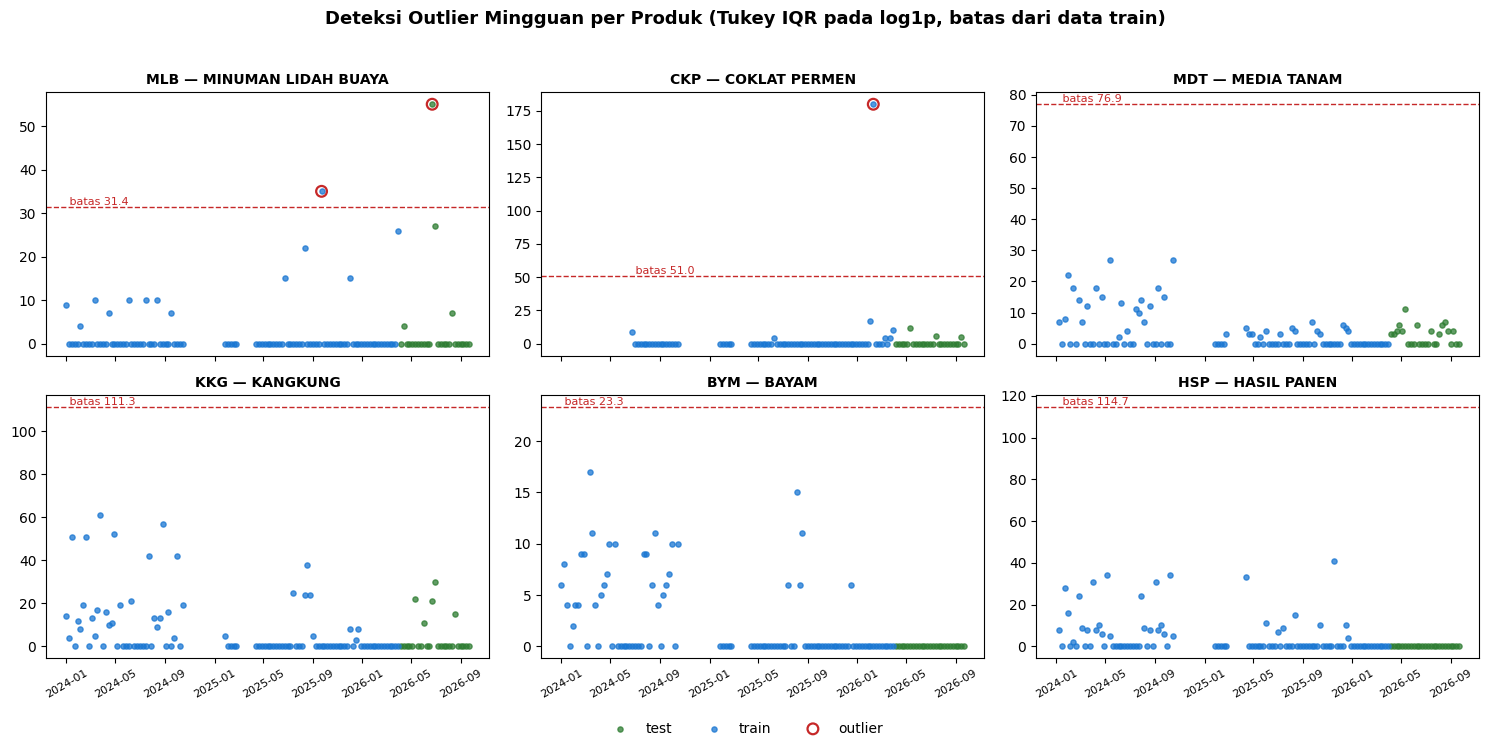

In [ ]:
dgn_outlier = tabel_batas.sort_values('n_outlier', ascending=False)['kode_produk'].tolist()
top = (dgn_outlier + [k for k in profil['kode_produk'] if k not in dgn_outlier])[:6]
warna_split = {'train': '#1976D2', 'test': '#2E7D32'}
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharex=True)
for ax, kode in zip(axes.ravel(), top):
    g = fact_mingguan[(fact_mingguan['kode_produk'] == kode) & (fact_mingguan['status_periode'] == 'operasional')]
    for sp, gg in g.groupby('split'):
        ax.scatter(gg['minggu_mulai'], gg['y'], s=14, color=warna_split[sp], alpha=0.75, label=sp)
    out = g[g['is_outlier']]
    ax.scatter(out['minggu_mulai'], out['y'], s=60, facecolors='none', edgecolors='#C62828', linewidths=1.6, label='outlier')
    b = batas[kode]
    if not np.isnan(b):
        ax.axhline(b, color='#C62828', ls='--', lw=1)
        ax.text(g['minggu_mulai'].min(), b, f' batas {b:.1f}', color='#C62828', fontsize=8, va='bottom')
    ax.set_title(f"{kode} — {PETA_NAMA[kode]}", fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=8)
h, l = axes[0, 0].get_legend_handles_labels()
fig.legend(h, l, loc='lower center', ncol=4, frameon=False)
fig.suptitle('Deteksi Outlier Mingguan per Produk (Tukey IQR pada log1p, batas dari data train)', fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 0.96]); simpan_fig(fig, '02_deteksi_outlier.png'); plt.show()

### Diagram: sebelum vs sesudah penanganan outlier (total demand toko per minggu)

**Kenapa ditampilkan?** Untuk memastikan capping outlier tidak menghilangkan pola aslinya (mis. lonjakan bazaar yang memang nyata), hanya meredam nilai yang secara statistik ekstrem.

Diagram tersimpan: /content/farmsight_output/diagram/03_sebelum_sesudah_outlier.png


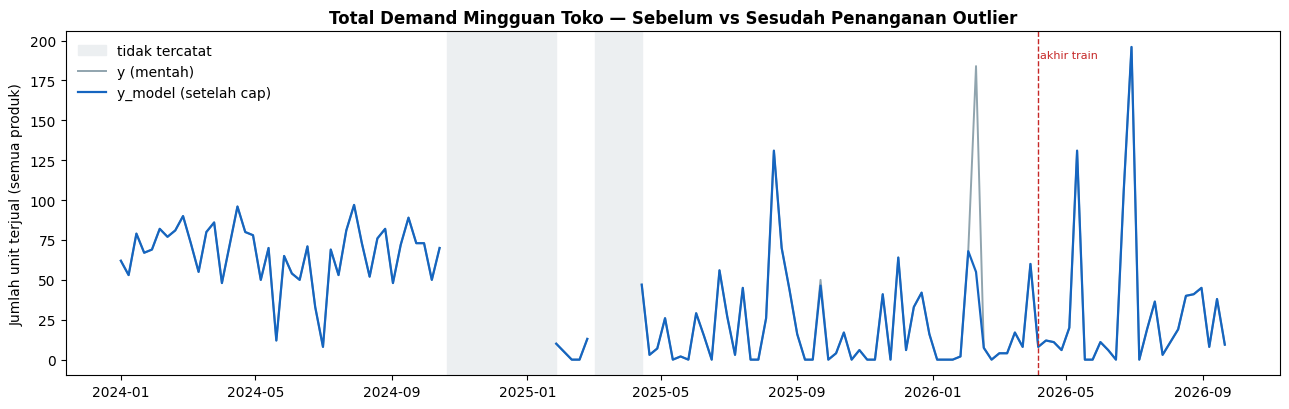

In [ ]:
tot = (fact_mingguan[fact_mingguan['status_periode'] == 'operasional']
       .groupby('minggu_mulai').agg(y=('y', 'sum'), y_model=('y_model', 'sum'))
       .reindex(kalender['minggu_mulai']).rename_axis('minggu_mulai').reset_index())   # minggu tidak tercatat = NaN (garis putus)
fig, ax = plt.subplots(figsize=(13, 4.2))
for _, r in gap.assign(blok=(gap['minggu_mulai'].diff().dt.days != 7).cumsum()).groupby('blok')['minggu_mulai'].agg(['min', 'max']).iterrows():
    ax.axvspan(r['min'], r['max'] + pd.Timedelta(days=7), color='#ECEFF1', label='tidak tercatat')
ax.plot(tot['minggu_mulai'], tot['y'], color='#90A4AE', lw=1.4, label='y (mentah)')
ax.plot(tot['minggu_mulai'], tot['y_model'], color='#1565C0', lw=1.6, label='y_model (setelah cap)')
for t, w in [(AKHIR_TRAIN, 'akhir train')]:
    ax.axvline(t + pd.Timedelta(days=7), color='#C62828', ls='--', lw=1); ax.text(t + pd.Timedelta(days=9), ax.get_ylim()[1] * 0.92, w, color='#C62828', fontsize=8)
h, l = ax.get_legend_handles_labels(); u = dict(zip(l, h))
ax.legend(u.values(), u.keys(), frameon=False, loc='upper left')
ax.set_title('Total Demand Mingguan Toko — Sebelum vs Sesudah Penanganan Outlier', fontsize=12, fontweight='bold')
ax.set_ylabel('Jumlah unit terjual (semua produk)')
plt.tight_layout(); simpan_fig(fig, '03_sebelum_sesudah_outlier.png'); plt.show()

### Diagram: pembagian train / test dan periode tidak tercatat

**Kenapa ditampilkan?** Supaya terlihat langsung apakah pembagian train/test kronologis ini masuk akal secara visual, dan di mana saja periode `tidak_tercatat` berada relatif terhadap split.

Diagram tersimpan: /content/farmsight_output/diagram/04_split_kronologis.png


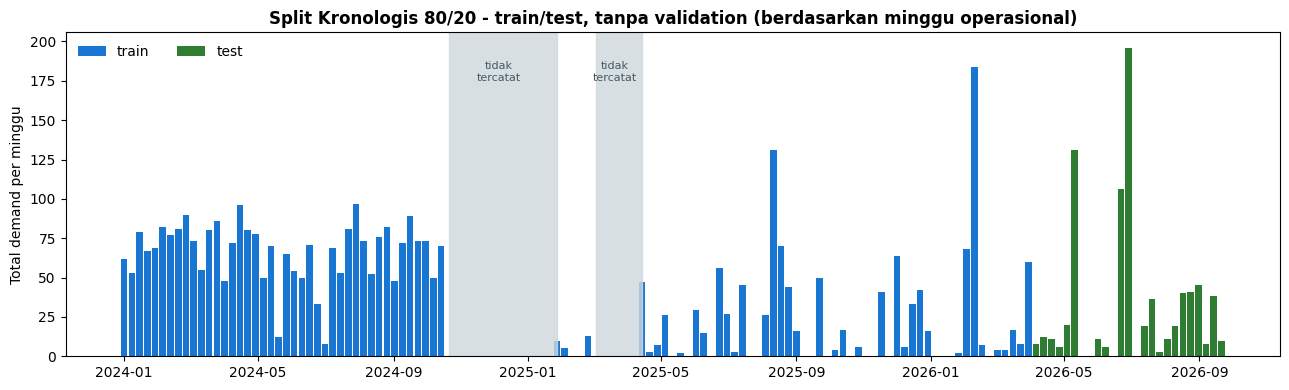

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))
tt = fact_mingguan[fact_mingguan['status_periode'] == 'operasional'].groupby(['minggu_mulai', 'split'])['y'].sum().reset_index()
for sp in ['train', 'test']:
    d = tt[tt['split'] == sp]
    ax.bar(d['minggu_mulai'], d['y'], width=6, color=warna_split[sp], label=f'{sp}')
for _, r in gap.assign(blok=(gap['minggu_mulai'].diff().dt.days != 7).cumsum()).groupby('blok')['minggu_mulai'].agg(['min', 'max']).iterrows():
    ax.axvspan(r['min'], r['max'] + pd.Timedelta(days=7), color='#CFD8DC', alpha=0.8)
    ax.text(r['min'] + (r['max'] - r['min']) / 2, ax.get_ylim()[1] * 0.85, 'tidak\ntercatat', ha='center', fontsize=8, color='#455A64')
ax.set_title('Split Kronologis 80/20 - train/test, tanpa validation (berdasarkan minggu operasional)', fontsize=12, fontweight='bold')
ax.set_ylabel('Total demand per minggu'); ax.legend(frameon=False, ncol=3, loc='upper left')
plt.tight_layout(); simpan_fig(fig, '04_split_kronologis.png'); plt.show()

### Diagram: peta pola demand (ADI vs CV²)

**Kenapa ditampilkan?** Untuk melihat sebaran ke-38 produk di keempat kuadran Syntetos–Boylan sekaligus — memperjelas kenapa hanya sebagian kecil produk yang realistis dimodelkan dengan ARIMA (kuadran *smooth/erratic*), sisanya *intermittent/lumpy*.

Diagram tersimpan: /content/farmsight_output/diagram/05_pola_demand_adi_cv2.png


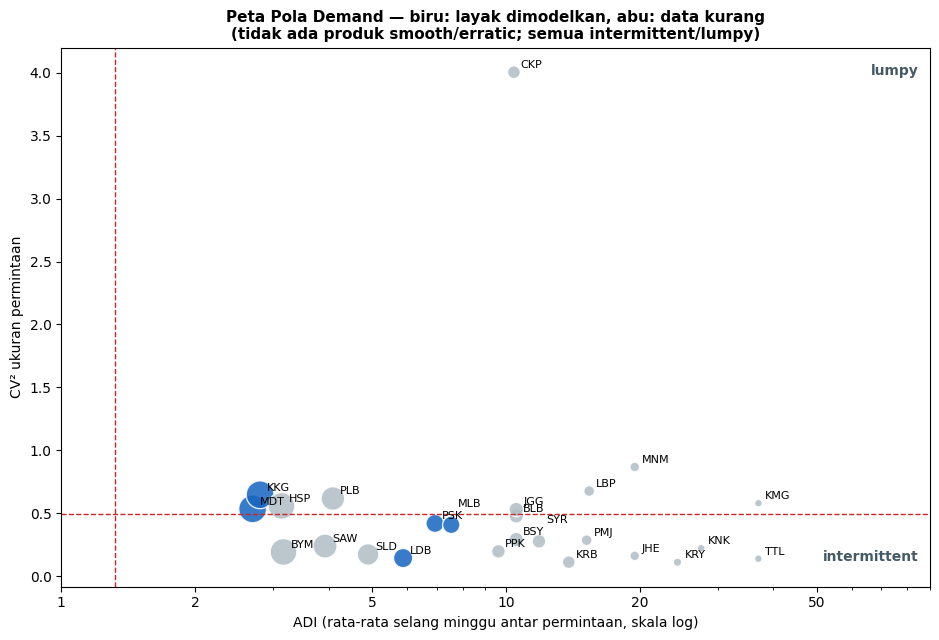

In [ ]:
p = profil.dropna(subset=['adi', 'cv2'])
fig, ax = plt.subplots(figsize=(9.5, 6.5))
ax.scatter(p['adi'], p['cv2'], s=np.clip(p['n_pos_train'] * 12, 30, 400),
           c=np.where(p['layak_model'], '#1565C0', '#B0BEC5'), alpha=0.85, edgecolors='white')
terpasang = []
for _, r in p.iterrows():                       # label tiap titik; titik yang hampir berhimpit digeser ke atas
    n = sum(abs(np.log10(r['adi']) - lx) < 0.06 and abs(r['cv2'] - ly) < 0.03 for lx, ly in terpasang)
    terpasang.append((np.log10(r['adi']), r['cv2']))
    ax.annotate(r['kode_produk'], (r['adi'], r['cv2']), fontsize=8, xytext=(5, 3 + 10 * n), textcoords='offset points')
ax.set_xscale('log'); ax.set_xlim(1, 90)
ax.set_xticks([1, 2, 5, 10, 20, 50]); ax.set_xticklabels(['1', '2', '5', '10', '20', '50'])
ax.axvline(ADI_CUTOFF, color='#C62828', ls='--', lw=1); ax.axhline(CV2_CUTOFF, color='#C62828', ls='--', lw=1)
ax.set_xlabel('ADI (rata-rata selang minggu antar permintaan, skala log)'); ax.set_ylabel('CV² ukuran permintaan')
ax.set_title('Peta Pola Demand — biru: layak dimodelkan, abu: data kurang\n(tidak ada produk smooth/erratic; semua intermittent/lumpy)', fontsize=11, fontweight='bold')
ym = ax.get_ylim()[1]
ax.text(85, ym * 0.97, 'lumpy', ha='right', va='top', fontsize=10, color='#455A64', fontweight='bold')
ax.text(85, CV2_CUTOFF * 0.42, 'intermittent', ha='right', va='top', fontsize=10, color='#455A64', fontweight='bold')
plt.tight_layout(); simpan_fig(fig, '05_pola_demand_adi_cv2.png'); plt.show()

## Tahap 5 — Data Storage
Sesuai jurnal, data hasil pengolahan disimpan terstruktur ke basis data yang menjadi sumber untuk semua komponen sistem.
Di sini dipakai **SQLite** (`farmsight.db`): satu file, tanpa server, langsung terbaca dari Streamlit lewat `sqlite3`/pandas.
Salinan CSV disimpan sebagai cadangan.

**Kenapa disimpan ke database, bukan langsung dipakai dari notebook ini?** Supaya notebook pengolahan data dan
notebook pemodelan/dashboard tidak saling bergantung — kalau data mentah berubah (transaksi baru masuk), cukup
jalankan ulang notebook ini sekali, dan seluruh sistem (pemodelan, dashboard) otomatis memakai data terbaru
tanpa perlu disalin manual. SQLite dipilih dibanding sekadar file CSV karena bisa menyimpan banyak tabel
sekaligus (fakta mingguan, profil produk, parameter lead time, dll.) dengan tipe data yang konsisten, dan bisa
di-query langsung dengan SQL saat dibutuhkan.

In [ ]:
def siap_simpan(df):
    d = df.copy()
    for c in d.columns:
        if pd.api.types.is_datetime64_any_dtype(d[c]):
            d[c] = d[c].dt.strftime('%Y-%m-%d')
        elif d[c].dtype == bool:
            d[c] = d[c].astype(int)
        elif str(d[c].dtype) in ('string', 'str', 'object'):
            d[c] = d[c].astype(object).where(d[c].notna(), None)
    return d

kolom_mingguan = ['kode_produk', 'minggu_mulai', 'tahun', 'kuartal', 'bulan', 'minggu_ke', 'status_periode', 'split',
                  'y', 'y_model', 'y_log1p', 'is_outlier', 'dicap', 'outlier_saat_bazaar', 'batas_atas_outlier',
                  'pendapatan', 'n_transaksi', 'n_hari_jual', 'ada_bazaar', 'ada_mini_bazaar', 'stok_masuk', 'n_batch_stok']
kolom_siklus = ['kode_produk', 'nama_produk', 'tanggal_pemesanan', 'tanggal_barang_masuk', 'tanggal_barang_keluar',
                'tanggal_siklus_berakhir', 'jumlah_produk_masuk', 'satuan_produk', 'demand_aktual_siklus', 'demand_siklus_hitung',
                'selisih_siklus', 'flag_siklus_tidak_cocok', 'sisa_stok', 'rasio_pemakaian', 'durasi_siklus_hari',
                'lt_pemasok_hari', 'flag_lt_pemasok_negatif', 'flag_overstock_ekstrem']
fs = fact_siklus_stok.copy()
fs['tanggal_siklus_berakhir'] = fs['tanggal_siklus_berakhir'].where(fs['tanggal_siklus_berakhir'] < TGL_TAK_HINGGA)

karantina_df = (pd.concat(KARANTINA, ignore_index=True) if KARANTINA else pd.DataFrame(columns=['sumber', 'alasan']))
karantina_df = karantina_df.drop_duplicates()
ringkasan_kualitas = pd.DataFrame([
    {'sumber': 'penjualan', 'baris_mentah': len(raw_jual), 'baris_lolos_validitas': len(jual), 'baris_dipakai_model': len(jual_pakai)},
    {'sumber': 'stok', 'baris_mentah': len(raw_stok), 'baris_lolos_validitas': len(stok), 'baris_dipakai_model': len(stok_pakai)}])

TABEL = {
    'dim_produk': dim_produk,
    'fact_demand_mingguan': fact_mingguan[kolom_mingguan],
    'fact_demand_harian': demand_harian,
    'fact_siklus_stok': fs[kolom_siklus],
    'param_lead_time': param_lead_time,
    'param_operasional': param_operasional,
    'profil_produk': profil,
    'batas_outlier': batas_outlier,
    'ringkasan_periode': ringkasan_periode,
    'split_info': cut,
    'kalender_mingguan': kalender,
    'log_audit_pembersihan': pd.DataFrame(LOG),
    'karantina_data': karantina_df,
    'ringkasan_kualitas': ringkasan_kualitas,
}

DB_PATH = os.path.join(OUT_DIR, 'farmsight.db')
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)
con = sqlite3.connect(DB_PATH)
for nama, df in TABEL.items():
    siap_simpan(df).to_sql(nama, con, index=False, if_exists='replace')
    siap_simpan(df).to_csv(os.path.join(OUT_DIR, 'csv', f'{nama}.csv'), index=False)
con.executescript("""
CREATE INDEX IF NOT EXISTS ix_mingguan_produk ON fact_demand_mingguan(kode_produk, minggu_mulai);
CREATE INDEX IF NOT EXISTS ix_mingguan_split  ON fact_demand_mingguan(split);
CREATE INDEX IF NOT EXISTS ix_harian_produk   ON fact_demand_harian(kode_produk, tanggal);
CREATE INDEX IF NOT EXISTS ix_siklus_produk   ON fact_siklus_stok(kode_produk, tanggal_barang_keluar);
""")
con.commit()

config = {'tanggal_acuan': str(TANGGAL_MAKS.date()), 'frekuensi': 'mingguan (Senin-Minggu)', 'format_tanggal_sumber': FORMAT_TANGGAL,
          'split': {'akhir_train': str(AKHIR_TRAIN.date()),
                    'rasio': [RASIO_TRAIN, round(1 - RASIO_TRAIN, 2)]},
          'outlier': {'metode': 'Tukey IQR pada log1p per produk, dihitung dari train', 'k': IQR_K, 'min_pos': MIN_POS_OUTLIER,
                      'dicap_pada': ['train']},
          'periode_tidak_tercatat_min_minggu': MIN_GAP_MINGGU, 'buang_tanggal_masa_depan': BUANG_TANGGAL_MASA_DEPAN,
          'kelayakan_model': {'min_pos_train': MIN_POS_TRAIN_MODEL, 'min_pos_test': MIN_POS_TEST_MODEL},
          'tenaga_kerja': TENAGA_KERJA}
with open(os.path.join(OUT_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

# verifikasi baca-ulang dari database
print('Tabel di farmsight.db:')
for nama, df in TABEL.items():
    n_db = con.execute(f'SELECT COUNT(*) FROM {nama}').fetchone()[0]
    print(f'  {nama:26s} {n_db:6d} baris  (sumber: {len(df)})', 'OK' if n_db == len(df) else '<< TIDAK SAMA')
cek = pd.read_sql('SELECT SUM(y) AS total_y FROM fact_demand_mingguan', con).iloc[0, 0]
print(f'Cek total demand di DB = {cek:,.1f} (harus = {fact_mingguan["y"].sum():,.1f})')
con.close()

Tabel di farmsight.db:
  dim_produk                     38 baris  (sumber: 38) OK
  fact_demand_mingguan         5434 baris  (sumber: 5434) OK
  fact_demand_harian            584 baris  (sumber: 584) OK
  fact_siklus_stok              134 baris  (sumber: 134) OK
  param_lead_time                38 baris  (sumber: 38) OK
  param_operasional               2 baris  (sumber: 2) OK
  profil_produk                  38 baris  (sumber: 38) OK
  batas_outlier                  38 baris  (sumber: 38) OK
  ringkasan_periode               6 baris  (sumber: 6) OK
  split_info                      2 baris  (sumber: 2) OK
  kalender_mingguan             143 baris  (sumber: 143) OK
  log_audit_pembersihan          34 baris  (sumber: 34) OK
  karantina_data                 70 baris  (sumber: 70) OK
  ringkasan_kualitas              2 baris  (sumber: 2) OK
Cek total demand di DB = 4,784.3 (harus = 4,784.3)


### Kamus data (kolom utama)

In [ ]:
kamus = pd.DataFrame([
    ('fact_demand_mingguan', 'y', 'Demand mingguan mentah (unit jual). NaN jika periode tidak tercatat / produk belum dijual. GUNAKAN untuk evaluasi.'),
    ('fact_demand_mingguan', 'y_model', 'Demand setelah cap outlier (train saja). GUNAKAN untuk melatih model. Test = sama dengan y.'),
    ('fact_demand_mingguan', 'y_log1p', 'log1p(y_model). Jika model dilatih pada skala ini, kembalikan hasil dengan np.expm1.'),
    ('fact_demand_mingguan', 'split', 'train / test (kronologis; tanggal potong ada di split_info & config.json).'),
    ('fact_demand_mingguan', 'status_periode', 'operasional / tidak_tercatat / sebelum_produk_dijual / di_luar_rentang. Hanya "operasional" yang dipakai model.'),
    ('fact_demand_mingguan', 'is_outlier / dicap', 'Outlier terdeteksi / benar-benar dicap (test tidak pernah dicap).'),
    ('fact_demand_mingguan', 'ada_bazaar, ada_mini_bazaar', 'Ada event pada minggu tsb. Aman dipakai sebagai regresor (jadwal event diketahui sebelumnya).'),
    ('fact_demand_mingguan', 'stok_masuk, n_batch_stok', 'Info persediaan. JANGAN dipakai sebagai regresor forecasting (jumlah masuk dipengaruhi demand).'),
    ('fact_siklus_stok', 'demand_aktual_siklus', 'Total penjualan dalam satu siklus stok (turunan dari penjualan). Untuk Safety Stock/ROP, bukan fitur.'),
    ('fact_siklus_stok', 'sisa_stok, rasio_pemakaian', 'Jumlah masuk - demand siklus; demand siklus / jumlah masuk.'),
    ('param_lead_time', 'lead_time_hari', 'Median lead time valid per produk, fallback median global. PERLU dikonfirmasi maknanya.'),
    ('profil_produk', 'pola_demand, layak_model, saran_metode', 'Klasifikasi ADI/CV² dan kelayakan ARIMA/Prophet (dari train).'),
    ('karantina_data', '*', 'Semua baris yang dibuang/dikeluarkan beserta alasannya.'),
    ('log_audit_pembersihan', '*', 'Catatan setiap aturan cleaning: jumlah baris terdampak & tindakan.'),
], columns=['tabel', 'kolom', 'keterangan'])
kamus.to_csv(os.path.join(OUT_DIR, 'csv', 'kamus_data.csv'), index=False)
display(kamus)

,tabel,kolom,keterangan
0,fact_demand_mingguan,y,Demand mingguan mentah (unit jual). NaN jika p...
1,fact_demand_mingguan,y_model,Demand setelah cap outlier (train saja). GUNAK...
2,fact_demand_mingguan,y_log1p,log1p(y_model). Jika model dilatih pada skala ...
3,fact_demand_mingguan,split,train / test (kronologis; tanggal potong ada d...
4,fact_demand_mingguan,status_periode,operasional / tidak_tercatat / sebelum_produk_...
5,fact_demand_mingguan,is_outlier / dicap,Outlier terdeteksi / benar-benar dicap (test t...
6,fact_demand_mingguan,"ada_bazaar, ada_mini_bazaar",Ada event pada minggu tsb. Aman dipakai sebaga...
7,fact_demand_mingguan,"stok_masuk, n_batch_stok",Info persediaan. JANGAN dipakai sebagai regres...
8,fact_siklus_stok,demand_aktual_siklus,Total penjualan dalam satu siklus stok (turuna...
9,fact_siklus_stok,"sisa_stok, rasio_pemakaian",Jumlah masuk - demand siklus; demand siklus / ...


## Ringkasan hasil pengolahan

In [ ]:
print('=' * 70)
print('RINGKASAN')
print('=' * 70)
print(f'Penjualan : {len(raw_jual)} baris mentah -> {len(jual_pakai)} baris dipakai')
print(f'Stok      : {len(raw_stok)} baris mentah -> {len(stok_pakai)} baris dipakai')
print(f'Produk    : {len(dim_produk)} | layak ARIMA/Prophet: {int(profil["layak_model"].sum())}')
print(f'Deret     : {kalender.shape[0]} minggu, {int((~kalender["tidak_tercatat"]).sum())} operasional')
print(f'Split     : train s/d {AKHIR_TRAIN.date()} | test s/d {minggu_ops.iloc[-1].date()} (tanpa validation)')
print(f'Outlier   : {int(fact_mingguan["is_outlier"].sum())} terdeteksi, {int(fact_mingguan["dicap"].sum())} dicap')
print(f'Database  : {DB_PATH}')

RINGKASAN
Penjualan : 723 baris mentah -> 695 baris dipakai
Stok      : 176 baris mentah -> 134 baris dipakai
Produk    : 38 | layak ARIMA/Prophet: 5
Deret     : 143 minggu, 123 operasional
Split     : train s/d 2026-03-30 | test s/d 2026-09-21 (tanpa validation)
Outlier   : 3 terdeteksi, 2 dicap
Database  : /content/farmsight_output/farmsight.db


## Cara memakai hasil di tahap berikutnya
```python
import sqlite3, pandas as pd, json
con = sqlite3.connect('farmsight.db')
cfg = json.load(open('config.json'))

df = pd.read_sql("""SELECT minggu_mulai, split, y, y_model, ada_bazaar, ada_mini_bazaar
                    FROM fact_demand_mingguan
                    WHERE kode_produk = 'KKG' AND status_periode = 'operasional'
                    ORDER BY minggu_mulai""", con, parse_dates=['minggu_mulai'])

train = df[df.split == 'train']; test = df[df.split == 'test']
# Latih pada train['y_model'] -> tuning hyperparameter lewat rolling-origin backtest DI DALAM train ->
# evaluasi akhir di test['y'] (mentah), test tidak pernah dipakai utk tuning/pemilihan model
```
**Catatan:** minggu `tidak_tercatat` sengaja tidak diikutkan. Untuk Prophet cukup pakai baris `operasional` (Prophet menerima tanggal yang bolong).
Untuk ARIMA, `y` bernilai `NaN` di minggu tersebut, sehingga pakai `status_periode == 'operasional'` dan reindex ke frekuensi mingguan
(statsmodels menangani `NaN` pada ARIMA state-space), atau latih pada segmen terpanjang yang kontinu.

# FarmSight — Notebook 2: Demand Forecasting, Safety Stock & Reorder Point (DITINGKATKAN)
**Toko Farm Berkah**

Notebook ini melanjutkan `01_Pengolahan_Data_FarmSight.ipynb`. Sumber data satu-satunya adalah
`farmsight.db` (hasil notebook 1) — tidak membaca CSV mentah lagi.

**Sesuai permintaan, Prophet dihapus total.** Dari data yang ada, syarat minimum Prophet (jumlah
observasi & keteraturan musiman yang cukup) tidak ideal terpenuhi, sehingga hasilnya kurang bisa
diandalkan. Sekarang hanya **2 metode** yang dibandingkan/dipakai: **ARIMA** dan **Croston/SBA**
(tidak ada baseline naive/moving-average/SES, tidak ada TSB, tidak ada ensemble, tidak ada Prophet).
`f_naive` tetap ada di kode tapi hanya sebagai (a) fallback otomatis saat ARIMA gagal fit karena data
terlalu sedikit, dan (b) penyebut metrik MASE — bukan sebagai metode yang ikut dibandingkan/dipilih.

**Perbaikan lain atas versi sebelumnya (ditandai `BARU` di kode):**
1. **ARIMA dilatih pada skala `log1p`** (bukan skala mentah) lalu dikembalikan dengan `expm1` — cocok untuk demand yang miring ke kanan (lumpy/intermittent).
2. **Hyperparameter benar-benar di-tuning** (order ARIMA, `alpha` Croston/SBA) lewat grid search — **BARU (v3): tanpa validation split terpisah**, karena data historisnya sedikit. Tuning dilakukan lewat *rolling-origin backtest* di dalam **train saja** (evaluasi jalan-maju titik demi titik, riwayat sebelum tiap titik jadi "history"); `test` sama sekali tidak disentuh.
3. **Regresor event** (`ada_bazaar`, `ada_mini_bazaar`) dimasukkan ke ARIMA (jadi SARIMAX) — sebelumnya cuma dihitung tapi tidak dipakai model manapun.
4. **MASE** (Mean Absolute Scaled Error) ditambahkan sebagai pendamping MAPE — MAPE meledak secara semu pada demand intermittent (banyak minggu aktual = 0); MASE membandingkan terhadap tebakan naive sehingga lebih adil dibaca.
5. **Ambang kelayakan dipisah dua tingkat**: produk dengan data lebih sedikit sekarang tetap bisa dapat forecast berbasis Croston/SBA (tier `ringan`), bukan langsung jatuh ke rata-rata heuristik seperti sebelumnya — cakupan produk yang dimodelkan bertambah.
6. **Pemilihan model terbaik pakai RMSE dari rolling-origin backtest di dalam `train`** (bukan `val`+`test` lagi), sementara MAE/RMSE/MAPE/MASE yang dilaporkan ke pengguna tetap dihitung khusus dari `test` saja supaya evaluasi akhirnya jujur/tidak bocor.

| Tahap | Isi |
|---|---|
| 1 | Muat data siap pakai dari `farmsight.db` + tentukan tier kelayakan pemodelan per produk |
| 2 | Fungsi forecasting: Croston/SBA, ARIMA (log1p + regresor) |
| 3 | **Tuning hyperparameter lewat rolling-origin backtest di dalam `train` (baru v3, tanpa `val`)**, rolling forecast di `test` |
| 4 | Evaluasi MAE/RMSE/MAPE/**MASE (baru)**, pilih model terbaik dari **backtest di dalam train (baru v3)** |
| 5 | Forecast ke depan (horizon N minggu) dengan model terbaik (mendukung regresor) |
| 6 | **Safety Stock** & **Reorder Point** per produk (kini mencakup lebih banyak produk) |
| 7 | Simpan hasil ke `farmsight.db` (dipakai dashboard Streamlit), termasuk tabel hyperparameter |

**Catatan dari notebook 1:** hanya sebagian kecil dari 38 produk yang punya cukup data historis
(transaksi mentah cuma ±700 baris untuk 38 produk) — ini batas keras dari data, bukan dari model.
Perbaikan di atas memaksimalkan apa yang bisa digali dari data sekecil ini, tapi peningkatan akurasi
paling besar ke depannya tetap akan datang dari **menambah histori data transaksi**.


## 0. Setup & Konfigurasi
Semua parameter pemodelan ada di sini. Bagian bertanda `BARU` adalah tambahan dibanding versi sebelumnya.

In [ ]:
import os, json, sqlite3, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

OUT_DIR = os.environ.get('FARMSIGHT_OUT', '/content/farmsight_output')
DB_PATH = os.path.join(OUT_DIR, 'farmsight.db')
os.makedirs(os.path.join(OUT_DIR, 'diagram'), exist_ok=True)

# ---------- PARAMETER PEMODELAN ----------
HORIZON_MINGGU = 4          # berapa minggu ke depan yang diramalkan untuk rekomendasi stok
SERVICE_LEVEL = 0.95        # target tingkat layanan untuk Safety Stock
MIN_TEST_UNTUK_EVAL = 2     # minimal minggu ber-demand (>0) di test agar MAPE dianggap bermakna

# --- BARU (v3): tanpa validation split -> tuning hyperparameter lewat rolling-origin backtest DI DALAM train ---
MIN_HISTORY_TUNING = 8      # riwayat minimum (minggu) sebelum sebuah titik train dipakai utk membandingkan kandidat
                            # hyperparameter (selaras dgn syarat minimum f_arima, lihat definisinya di bawah)

# --- BARU: ambang kelayakan terpisah untuk metode intermittent-demand ---
# ARIMA butuh data jauh lebih banyak drpd Croston agar tidak overfit.
# Ambang di bawah ini mengizinkan produk dengan data lebih sedikit tetap mendapat
# forecast berbasis model (Croston/SBA) alih-alih hanya rata-rata heuristik.
MIN_POS_TRAIN_CROSTON = 5
MIN_POS_TEST_CROSTON = 1

# --- BARU: fit ARIMA pada skala log1p (data lumpy, miring ke kanan) ---
GUNAKAN_LOG1P = True

# --- BARU: sertakan event (bazaar / mini bazaar) sbg regresor ARIMA(X) ---
# Aman dipakai karena jadwal event diketahui sebelumnya (lihat kamus_data notebook 1).
PAKAI_REGRESOR_EVENT = True

# --- BARU: jadwal event yang SUDAH DIKETAHUI untuk minggu-minggu ke depan (di luar data historis).
# Isi manual kalau ada bazaar/mini-bazaar terjadwal pada horizon forecast; default = tidak ada event.
# format: {'YYYY-MM-DD' (Senin awal minggu): (ada_bazaar, ada_mini_bazaar)}
JADWAL_EVENT_KEDEPAN = {}

# --- BARU (v3): grid hyperparameter untuk tuning lewat backtest DI DALAM TRAIN (bukan val, bukan test) ---
GRID_ARIMA_ORDER = [(0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1), (1, 1, 2)]
GRID_ALPHA_CROSTON = [0.1, 0.15, 0.2, 0.3]

from scipy.stats import norm
Z_SERVICE = float(norm.ppf(SERVICE_LEVEL))
print(f'Service level {SERVICE_LEVEL:.0%} -> Z = {Z_SERVICE:.3f}')
print(f'Fit ARIMA pada skala log1p: {GUNAKAN_LOG1P} | Regresor event (bazaar): {PAKAI_REGRESOR_EVENT}')

con = sqlite3.connect(DB_PATH)
cfg = json.load(open(os.path.join(OUT_DIR, 'config.json')))
print('Konfigurasi dari notebook 1:', json.dumps(cfg, indent=2, ensure_ascii=False))

Service level 95% -> Z = 1.645
Fit ARIMA pada skala log1p: True | Regresor event (bazaar): True
Konfigurasi dari notebook 1: {
  "tanggal_acuan": "2026-10-02",
  "frekuensi": "mingguan (Senin-Minggu)",
  "format_tanggal_sumber": "%m/%d/%y",
  "split": {
    "akhir_train": "2026-03-30",
    "rasio": [
      0.8,
      0.2
    ]
  },
  "outlier": {
    "metode": "Tukey IQR pada log1p per produk, dihitung dari train",
    "k": 1.5,
    "min_pos": 8,
    "dicap_pada": [
      "train"
    ]
  },
  "periode_tidak_tercatat_min_minggu": 4,
  "buang_tanggal_masa_depan": true,
  "kelayakan_model": {
    "min_pos_train": 12,
    "min_pos_test": 2
  },
  "tenaga_kerja": 10
}


## 1. Muat data & tentukan tier kelayakan pemodelan
**BARU — dua ambang, bukan satu.** Sebelumnya hanya produk yang lolos syarat ARIMA (`profil_produk.layak_model`,
minimal 12 minggu ber-demand di train) yang dapat forecast berbasis model; produk lain langsung dikasih
rata-rata heuristik. Sekarang ada tier tengah: produk dengan data lebih sedikit tapi masih cukup untuk
Croston/SBA (`MIN_POS_TRAIN_CROSTON`/`MIN_POS_TEST_CROSTON`) tetap dapat forecast berbasis Croston/SBA,
bukan cuma rata-rata mentah. ARIMA tetap dihitung untuk tier ini juga, tapi karena datanya sedikit
(< 8 observasi) otomatis fallback ke naive dan biasanya kalah dari Croston/SBA.

In [ ]:
dim_produk = pd.read_sql('SELECT * FROM dim_produk', con)
profil = pd.read_sql('SELECT * FROM profil_produk', con)
mingguan = pd.read_sql('SELECT * FROM fact_demand_mingguan', con, parse_dates=['minggu_mulai'])
param_lt = pd.read_sql('SELECT * FROM param_lead_time', con)
param_ops = pd.read_sql('SELECT * FROM param_operasional', con)

def ambil_deret(kode):
    """Deret mingguan lengkap (operasional saja) untuk satu produk, terindeks minggu_mulai."""
    g = mingguan[(mingguan['kode_produk'] == kode) & (mingguan['status_periode'] == 'operasional')].sort_values('minggu_mulai')
    return g.set_index('minggu_mulai')

# --- Tier kelayakan pemodelan (BARU: dua ambang, bukan satu) ---
# 'penuh'     -> cukup data untuk ARIMA juga (syarat asli notebook 1: profil_produk.layak_model)
# 'ringan'    -> data terlalu sedikit utk ARIMA yg wajar, tapi cukup utk Croston/SBA
# 'heuristik' -> data terlalu sedikit utk metode apa pun -> pakai rata-rata & std mentah (seperti semula)
def tentukan_tier(r):
    if r['status_produk'] != 'aktif':
        return 'tidak_aktif'
    if r['layak_model']:
        return 'penuh'
    if r['n_pos_train'] >= MIN_POS_TRAIN_CROSTON and r['n_pos_test'] >= MIN_POS_TEST_CROSTON:
        return 'ringan'
    return 'heuristik'

profil['tier_model'] = profil.apply(tentukan_tier, axis=1)
produk_layak = profil.loc[profil['tier_model'] == 'penuh', 'kode_produk'].tolist()
produk_ringan = profil.loc[profil['tier_model'] == 'ringan', 'kode_produk'].tolist()
produk_model = produk_layak + produk_ringan          # semua produk yang lewat rolling_forecast/evaluasi
produk_heuristik = profil.loc[profil['tier_model'] == 'heuristik', 'kode_produk'].tolist()

print(f"Tier 'penuh' (ARIMA+Croston): {len(produk_layak)} produk -> {produk_layak}")
print(f"Tier 'ringan' (Croston saja, ARIMA otomatis fallback ke naive): {len(produk_ringan)} produk -> {produk_ringan}")
print(f"Tier 'heuristik' (data terlalu sedikit, pakai rata-rata & std mentah): {len(produk_heuristik)} produk")
display(profil[profil['kode_produk'].isin(produk_model)]
        [['kode_produk', 'nama_produk', 'pola_demand', 'tier_model', 'n_pos_train', 'n_pos_test']]
        .sort_values(['tier_model', 'n_pos_train'], ascending=[True, False]))

Tier 'penuh' (ARIMA+Croston): 5 produk -> ['MDT', 'KKG', 'LDB', 'PSK', 'MLB']
Tier 'ringan' (Croston saja, ARIMA otomatis fallback ke naive): 4 produk -> ['PPK', 'CKP', 'PMJ', 'LBP']
Tier 'heuristik' (data terlalu sedikit, pakai rata-rata & std mentah): 14 produk


,kode_produk,nama_produk,pola_demand,tier_model,n_pos_train,n_pos_test
0,MDT,MEDIA TANAM,lumpy,penuh,36.0,13.0
1,KKG,KANGKUNG,lumpy,penuh,35.0,5.0
7,LDB,LIDAH BUAYA,intermittent,penuh,16.0,3.0
8,PSK,PISANG KEPOK,intermittent,penuh,14.0,7.0
9,MLB,MINUMAN LIDAH BUAYA,intermittent,penuh,13.0,4.0
13,PPK,PUPUK,intermittent,ringan,8.0,9.0
16,CKP,COKLAT PERMEN,lumpy,ringan,7.0,3.0
17,PMJ,PERMEN JELLY,intermittent,ringan,5.0,3.0
18,LBP,LABU PRIDA,lumpy,ringan,5.0,2.0


## 2. Fungsi forecasting: Croston/SBA & ARIMA
Hanya 2 metode ini yang dibandingkan (Prophet dihapus — tidak cocok untuk data sekecil/sejarang ini).
**BARU:** `f_arima` kini punya opsi fit di skala `log1p` (`GUNAKAN_LOG1P`) serta opsi regresor eksogen
`ada_bazaar`/`ada_mini_bazaar` (`PAKAI_REGRESOR_EVENT`) — otomatis berubah jadi SARIMAX kalau regresor diberikan.

In [ ]:
def f_naive(history, **kw):
    return float(history[-1]) if len(history) else 0.0

def f_croston_sba(history, alpha=0.2, **kw):
    """Croston's method dengan koreksi bias Syntetos-Boylan (SBA) — standar untuk intermittent demand.
    Melacak level permintaan (saat terjadi) dan interval antar kejadian secara terpisah."""
    history = np.asarray(history, dtype=float)
    idx_taknol = np.flatnonzero(history > 0)
    if len(idx_taknol) == 0:
        return 0.0
    if len(idx_taknol) == 1:
        return float(history[idx_taknol[0]] / 2)   # sedikit konservatif, hindari over-forecast dari 1 titik
    z = history[idx_taknol[0]]                       # level permintaan
    p = idx_taknol[0] + 1                            # interval awal
    interval_terakhir = idx_taknol[0] + 1
    for i in idx_taknol[1:]:
        interval = i - interval_terakhir + 1
        z = alpha * history[i] + (1 - alpha) * z
        p = alpha * interval + (1 - alpha) * p
        interval_terakhir = i + 1
    return float((1 - alpha / 2) * z / p)            # faktor (1 - alpha/2) = koreksi bias SBA

def f_arima(history, order=(1, 1, 1), exog_hist=None, exog_future=None, use_log=True, **kw):
    """ARIMA/SARIMAX (statsmodels). BARU: opsi fit di skala log1p (data lumpy, miring kanan) dan
    opsi regresor eksogen (exog) mis. jadwal bazaar -> otomatis pakai SARIMAX kalau exog diberikan.
    Perlu >= 8 observasi; jatuh ke naive kalau fitting gagal (data terlalu jarang)."""
    try:
        if len(history) < 8:
            raise ValueError('data terlalu sedikit untuk ARIMA')
        h = np.asarray(history, dtype=float)
        y_fit = np.log1p(h) if use_log else h
        if exog_hist is not None:
            from statsmodels.tsa.statespace.sarimax import SARIMAX
            model = SARIMAX(y_fit, order=order, exog=np.asarray(exog_hist, dtype=float),
                             enforce_stationarity=False, enforce_invertibility=False)
            hasil = model.fit(disp=False)
            ef = np.asarray(exog_future, dtype=float).reshape(1, -1)
            fc = hasil.forecast(steps=1, exog=ef)
            pred = float(np.asarray(fc)[0])
        else:
            from statsmodels.tsa.arima.model import ARIMA
            model = ARIMA(y_fit, order=order)
            hasil = model.fit()
            pred = float(hasil.forecast()[0])
        pred = np.expm1(pred) if use_log else pred
        return float(max(pred, 0))
    except Exception:
        return f_naive(history)

MODEL_TERSEDIA = {'arima': True}
try:
    import statsmodels  # noqa
except ImportError:
    MODEL_TERSEDIA['arima'] = False
    print('PERINGATAN: statsmodels tidak terpasang -> ARIMA memakai fallback naive.\n'
          '  Di Google Colab, statsmodels sudah terpasang bawaan; tidak perlu instalasi tambahan.')

METODE_ARIMA_TERSEDIA = MODEL_TERSEDIA['arima']

# Sesuai permintaan: PROPHET DIHAPUS. Hanya 2 metode yang dibandingkan/dipakai: ARIMA & Croston/SBA
# (dari data yang ada, syarat minimum Prophet -- terutama jumlah observasi & regularitas musiman -- tidak
# terpenuhi, sehingga hasilnya tidak ideal). f_naive tetap ada di kode karena dipakai sbg (a) fallback
# internal saat ARIMA gagal fit (data terlalu sedikit) dan (b) penyebut MASE (skala error pembanding)
# -- bukan sbg metode yang bersaing.
METODE_DASAR = ['croston_sba', 'arima']
METODE = METODE_DASAR
print('Metode yang dibandingkan:', METODE_DASAR)


Metode yang dibandingkan: ['croston_sba', 'arima']


## 3. Tuning hyperparameter (BARU v3: rolling-origin backtest DI DALAM train) & Rolling Forecast
`prediksi_satu_metode()` adalah titik tunggal untuk menghasilkan satu prediksi dari satu metode — dipakai baik
saat rolling forecast (evaluasi) maupun forecast ke depan (ekstrapolasi), supaya logikanya konsisten.

**BARU (v3) — tanpa `val` split.** Data historisnya sedikit, jadi menyisihkan validation terpisah akan memotong
train yang sudah kecil itu makin kecil lagi. `tuning_kode()` sekarang men-grid-search hyperparameter tiap metode
(order ARIMA, `alpha` Croston/SBA) lewat **rolling-origin backtest di dalam `train` itu sendiri**: untuk tiap titik
train dari indeks `MIN_HISTORY_TUNING` dan seterusnya, riwayat *sebelum* titik itu dipakai sebagai "history" untuk
memprediksi titik tersebut — persis logika yang sama dengan rolling forecast di `test`, hanya saja dilakukan di
dalam `train`. `test` sama sekali tidak disentuh untuk tuning maupun pemilihan model.


In [ ]:
# BARU (v3): satu fungsi terpusat untuk "hasilkan 1 prediksi dgn 1 metode", dipakai baik oleh rolling_forecast
# (evaluasi di test) maupun forecast_ke_depan (ekstrapolasi), supaya logikanya tidak dobel & konsisten.
HP = {}   # kode_produk -> hyperparameter terbaik (diisi oleh tuning_kode di bawah)

def prediksi_satu_metode(nama_metode, history, tanggal_history, kode, exog_hist=None, exog_future=None):
    hp = HP.get(kode, {})
    if nama_metode == 'croston_sba':
        return f_croston_sba(history, alpha=hp.get('croston_alpha', 0.2))
    if nama_metode == 'arima':
        if not METODE_ARIMA_TERSEDIA:
            return f_naive(history)
        eh = exog_hist if (PAKAI_REGRESOR_EVENT and exog_hist is not None) else None
        ef = exog_future if (PAKAI_REGRESOR_EVENT and exog_future is not None) else None
        return f_arima(history, order=hp.get('arima_order', (1, 1, 1)), exog_hist=eh, exog_future=ef, use_log=GUNAKAN_LOG1P)
    raise ValueError(f'metode tidak dikenal: {nama_metode}')

def tuning_kode(kode):
    """BARU (v3): cari hyperparameter terbaik per produk lewat rolling-origin backtest DI DALAM train
    (bukan validation split terpisah -- data historisnya sedikit, jadi tidak ada split ketiga).
    Titik-titik train dari indeks MIN_HISTORY_TUNING dan seterusnya dipakai sbg titik uji; riwayat SEBELUM
    titik itu jadi "history"-nya -- logikanya identik dengan rolling forecast di test, cuma dijalankan di
    dalam train. Test set tetap sama sekali tidak disentuh. Selain hyperparameter terbaik, dikembalikan juga
    RMSE backtest tiap metode dasar (dipakai lagi nanti utk MEMILIH metode terbaik per produk)."""
    g = ambil_deret(kode)
    y_penuh = g['y_model'].values
    y_aktual_penuh = g['y'].values
    split_arr = g['split'].values
    exog_penuh = g[['ada_bazaar', 'ada_mini_bazaar']].astype(float).values
    idx_train = np.flatnonzero(split_arr == 'train')
    idx_tune = idx_train[idx_train >= MIN_HISTORY_TUNING]

    default = dict(arima_order=(1, 1, 1), croston_alpha=0.2)
    if len(idx_tune) == 0:
        return default, {'arima': np.inf, 'croston_sba': np.inf}

    def skor(fn_kw):
        nama_metode, kw = fn_kw
        preds, actual = [], []
        for i in idx_tune:
            history = y_penuh[:i]
            if len(history) == 0:
                continue
            if nama_metode == 'arima':
                p = f_arima(history, exog_hist=(exog_penuh[:i] if PAKAI_REGRESOR_EVENT else None),
                            exog_future=(exog_penuh[i] if PAKAI_REGRESOR_EVENT else None), use_log=GUNAKAN_LOG1P, **kw)
            elif nama_metode == 'croston_sba':
                p = f_croston_sba(history, **kw)
            else:
                raise ValueError(nama_metode)
            preds.append(p); actual.append(y_aktual_penuh[i])
        if not preds:
            return np.inf
        return float(np.sqrt(np.mean((np.array(actual) - np.array(preds)) ** 2)))

    hp = dict(default)
    skor_terbaik = {}
    if METODE_ARIMA_TERSEDIA:
        hasil_skor = {o: skor(('arima', dict(order=o))) for o in GRID_ARIMA_ORDER}
        hp['arima_order'] = min(hasil_skor, key=hasil_skor.get)
        skor_terbaik['arima'] = hasil_skor[hp['arima_order']]
    else:
        skor_terbaik['arima'] = np.inf
    hasil_skor = {a: skor(('croston_sba', dict(alpha=a))) for a in GRID_ALPHA_CROSTON}
    hp['croston_alpha'] = min(hasil_skor, key=hasil_skor.get)
    skor_terbaik['croston_sba'] = hasil_skor[hp['croston_alpha']]
    return hp, skor_terbaik

print('Tuning hyperparameter per produk (rolling-origin backtest DI DALAM train, tanpa val)...')
SKOR_TUNING = {}
for kode in produk_model:
    HP[kode], SKOR_TUNING[kode] = tuning_kode(kode)
    print(f"  {kode}: {HP[kode]}  | RMSE backtest-train -> arima={SKOR_TUNING[kode]['arima']:.2f}, croston_sba={SKOR_TUNING[kode]['croston_sba']:.2f}")

def rolling_forecast(kode, split_target):
    """Kembalikan DataFrame minggu x (y_aktual, prediksi tiap metode dasar) untuk satu split.
    BARU (v3): sekarang cuma dipanggil dgn split_target='test' (tidak ada 'val' lagi)."""
    g = ambil_deret(kode)
    y_penuh = g['y_model'].values           # dipakai sebagai riwayat (sudah di-cap outlier pada train)
    y_aktual_penuh = g['y'].values          # dipakai sebagai kebenaran evaluasi (mentah)
    tanggal_penuh = g.index
    split_arr = g['split'].values
    exog_penuh = g[['ada_bazaar', 'ada_mini_bazaar']].astype(float).values

    baris = []
    idx_target = np.flatnonzero(split_arr == split_target)
    for i in idx_target:
        history = y_penuh[:i]
        if len(history) == 0:
            continue
        pred = {'minggu_mulai': tanggal_penuh[i], 'y_aktual': y_aktual_penuh[i]}
        for nama in METODE_DASAR:
            pred[nama] = prediksi_satu_metode(nama, history, tanggal_penuh[:i], kode,
                                               exog_hist=exog_penuh[:i], exog_future=exog_penuh[i])
        baris.append(pred)
    return pd.DataFrame(baris)

hasil_test = {}
for kode in produk_model:
    print(f'Menghitung rolling forecast test untuk {kode} ...')
    hasil_test[kode] = rolling_forecast(kode, 'test')
print('Selesai.')


Tuning hyperparameter per produk (rolling-origin backtest DI DALAM train, tanpa val)...


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  MDT: {'arima_order': (1, 1, 2), 'croston_alpha': 0.3}  | RMSE backtest-train -> arima=4.55, croston_sba=5.48


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local

  KKG: {'arima_order': (1, 1, 0), 'croston_alpha': 0.15}  | RMSE backtest-train -> arima=12.93, croston_sba=13.58


...

  CKP: {'arima_order': (1, 1, 0), 'croston_alpha': 0.1}  | RMSE backtest-train -> arima=23.03, croston_sba=22.48


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  PMJ: {'arima_order': (1, 1, 0), 'croston_alpha': 0.3}  | RMSE backtest-train -> arima=1.21, croston_sba=2.77


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local

  LBP: {'arima_order': (0, 1, 1), 'croston_alpha': 0.3}  | RMSE backtest-train -> arima=3.10, croston_sba=4.15
Menghitung rolling forecast test untuk MDT ...
Menghitung rolling forecast test untuk KKG ...
Menghitung rolling forecast test untuk LDB ...
Menghitung rolling forecast test untuk PSK ...
Menghitung rolling forecast test untuk MLB ...
Menghitung rolling forecast test untuk PPK ...
Menghitung rolling forecast test untuk CKP ...
Menghitung rolling forecast test untuk PMJ ...
Menghitung rolling forecast test untuk LBP ...
Selesai.


## 4. Evaluasi: MAE / RMSE / MAPE / MASE, pilih model terbaik
MASE ditambahkan karena MAPE meledak secara semu pada demand intermittent (pembagi dipaksa 1 saat aktual = 0).
MASE < 1 berarti model mengalahkan tebakan naive; > 1 berarti kalah — jauh lebih mudah dibaca untuk data sejarang ini.

**BARU (v3):** model terbaik sekarang dipilih berdasarkan RMSE dari **rolling-origin backtest di dalam `train`**
(hasil `tuning_kode()`/`SKOR_TUNING` di sel sebelumnya), BUKAN dari `val`+`test` gabungan lagi (karena `val` sudah
tidak ada). Metrik yang dilaporkan ke pengguna tetap dihitung **khusus dari `test`** (sama sekali tidak ikut proses
tuning maupun pemilihan) supaya angka akurasi akhirnya tetap jujur/tidak bocor.


In [ ]:
# MASE (Mean Absolute Scaled Error) sbg pelengkap MAPE ---
# MAPE meledak pada demand intermittent karena banyak minggu aktual = 0 (pembagi dipaksa 1).
# MASE membandingkan error model terhadap error naive satu-langkah DI DALAM TRAIN -> < 1 berarti
# model mengalahkan naive, > 1 berarti kalah. Lebih adil utk data jarang/lumpy.
TRAIN_NAIVE_MAE = {}
for kode in produk_model:
    tr = ambil_deret(kode)
    tr = tr.loc[tr['split'] == 'train', 'y'].dropna().values
    TRAIN_NAIVE_MAE[kode] = float(np.mean(np.abs(np.diff(tr)))) if len(tr) > 1 else np.nan

def hitung_metrik(df_hasil, nama_metode, mae_naive_train=np.nan):
    y = df_hasil['y_aktual'].values
    yhat = df_hasil[nama_metode].values
    mae = mean_absolute_error(y, yhat)
    rmse = np.sqrt(mean_squared_error(y, yhat))
    penyebut = np.where(y == 0, 1, y)          # hindari pembagian nol; standar dipakai di notebook awal
    mape = np.mean(np.abs((y - yhat) / penyebut)) * 100
    mase = mae / mae_naive_train if (mae_naive_train and not np.isnan(mae_naive_train) and mae_naive_train > 0) else np.nan
    n_pos = int((y > 0).sum())
    return dict(mae=mae, rmse=rmse, mape=mape, mase=mase, n_minggu=len(y), n_pos=n_pos,
                mape_bermakna=n_pos >= MIN_TEST_UNTUK_EVAL)

# BARU (v3): tidak ada 'val'/'gabungan' lagi -> baris_eval hanya berisi metrik dari TEST
baris_eval = []
for kode in produk_model:
    dt = hasil_test[kode]
    if dt.empty:
        continue
    for metode in METODE:
        m = hitung_metrik(dt, metode, TRAIN_NAIVE_MAE.get(kode, np.nan))
        baris_eval.append(dict(kode_produk=kode, split='test', metode=metode, **m))
eval_df = pd.DataFrame(baris_eval)

print("MAPE dihitung dengan pembagi = 1 pada minggu aktual 0 (mengikuti notebook awal), sehingga bisa")
print("sangat besar/kecil secara semu di data yang jarang -> gunakan MASE sbg pembanding utama, bukan MAPE.")
print(f"'mape_bermakna' = False artinya test punya < {MIN_TEST_UNTUK_EVAL} minggu ber-demand -> abaikan MAPE-nya.")
print("BARU (v3): model terbaik dipilih dari RMSE rolling-origin backtest DI DALAM TRAIN (SKOR_TUNING) --")
print("test sama sekali tidak ikut proses pemilihan. Tabel & metrik di bawah murni dari test (jujur/tidak bocor).")

tabel_rmse_test = eval_df.pivot(index='kode_produk', columns='metode', values='rmse').round(2)
tabel_rmse_test = tabel_rmse_test[[m for m in METODE if m in tabel_rmse_test.columns]]
display(tabel_rmse_test)

# --- BARU (v3): pilih model terbaik berdasar RMSE rolling-origin backtest DI DALAM TRAIN (SKOR_TUNING) ---
model_terbaik = pd.DataFrame([
    {'kode_produk': kode,
     'model_terbaik': min(SKOR_TUNING[kode], key=SKOR_TUNING[kode].get),
     'rmse_backtest_train': min(SKOR_TUNING[kode].values())}
    for kode in produk_model
])

# lampirkan metrik TEST SAJA (tidak ikut proses pemilihan) utk model yg terpilih -> pelaporan jujur
metrik_test = eval_df[['kode_produk', 'metode', 'mae', 'rmse', 'mape', 'mase', 'mape_bermakna']]
model_terbaik = model_terbaik.merge(metrik_test, left_on=['kode_produk', 'model_terbaik'], right_on=['kode_produk', 'metode'], how='left')
model_terbaik = model_terbaik.drop(columns=['metode']).merge(dim_produk[['kode_produk', 'nama_produk']], on='kode_produk')
model_terbaik = model_terbaik.merge(profil[['kode_produk', 'tier_model']], on='kode_produk')
display(model_terbaik)


MAPE dihitung dengan pembagi = 1 pada minggu aktual 0 (mengikuti notebook awal), sehingga bisa
sangat besar/kecil secara semu di data yang jarang -> gunakan MASE sbg pembanding utama, bukan MAPE.
'mape_bermakna' = False artinya test punya < 2 minggu ber-demand -> abaikan MAPE-nya.
BARU (v3): model terbaik dipilih dari RMSE rolling-origin backtest DI DALAM TRAIN (SKOR_TUNING) --
test sama sekali tidak ikut proses pemilihan. Tabel & metrik di bawah murni dari test (jujur/tidak bocor).


metode,croston_sba,arima
kode_produk,,
CKP,2.90,3.61
KKG,8.58,8.92
LBP,2.01,2.08
LDB,1.67,1.68
MDT,3.31,3.55
MLB,12.00,12.11
PMJ,1.44,2.39
PPK,2.92,2.99
PSK,1.99,1.87


,kode_produk,model_terbaik,rmse_backtest_train,mae,rmse,mape,mase,mape_bermakna,nama_produk,tier_model
0,MDT,arima,4.545525,2.676018,3.552821,95.557897,0.476619,True,MEDIA TANAM,penuh
1,KKG,arima,12.934920,5.234553,8.916355,198.122658,0.474534,True,KANGKUNG,penuh
2,LDB,arima,2.384667,0.790323,1.676310,33.513315,0.415254,True,LIDAH BUAYA,penuh
3,PSK,arima,7.586715,1.081877,1.873657,60.075998,0.286907,True,PISANG KEPOK,penuh
4,MLB,croston_sba,5.827931,5.370394,12.004413,214.272860,1.602856,True,MINUMAN LIDAH BUAYA,penuh
5,PPK,arima,1.515684,1.770105,2.991755,64.885032,1.747117,True,PUPUK,ringan
6,CKP,croston_sba,22.476629,2.423098,2.898838,182.876423,0.441679,True,COKLAT PERMEN,ringan
7,PMJ,arima,1.206012,1.141350,2.389059,84.705239,2.140032,True,PERMEN JELLY,ringan
8,LBP,arima,3.098615,0.688862,2.082149,18.034293,0.588242,True,LABU PRIDA,ringan


### Diagram: perbandingan RMSE antar metode (BARU v3: dari backtest di dalam train) & aktual vs prediksi (test)

**Kenapa ditampilkan?** Angka RMSE di tabel gampang dilewatkan; diagram batang & garis membuat langsung terlihat metode mana yang menang per produk dan seberapa jauh prediksi meleset dari pola aktualnya minggu demi minggu.


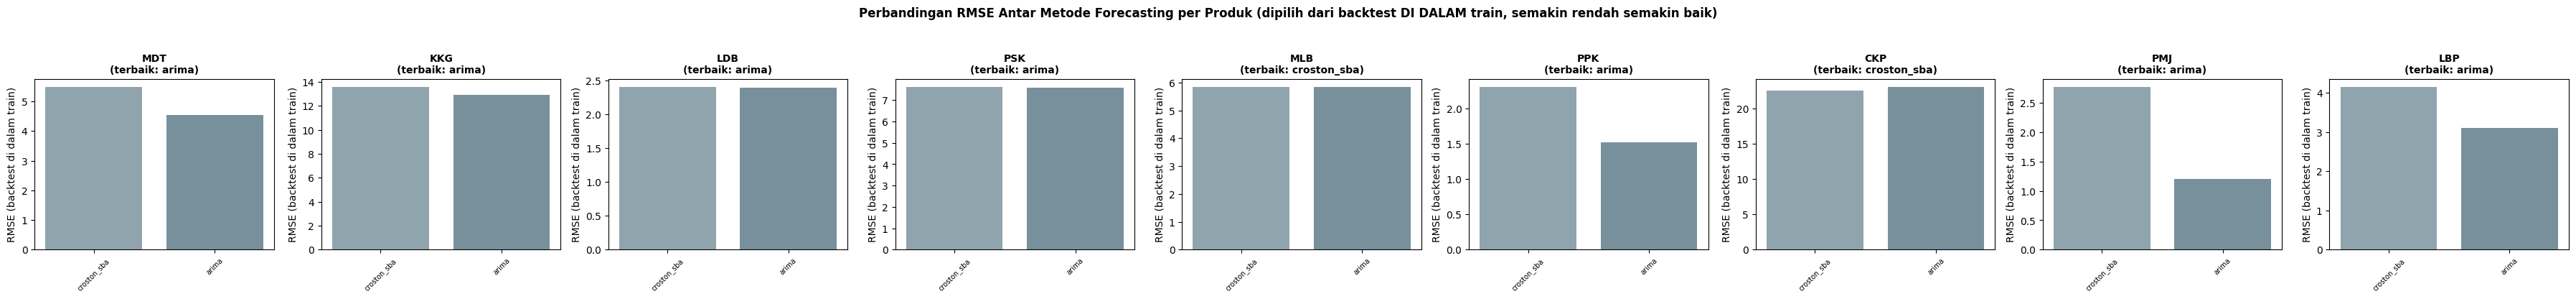

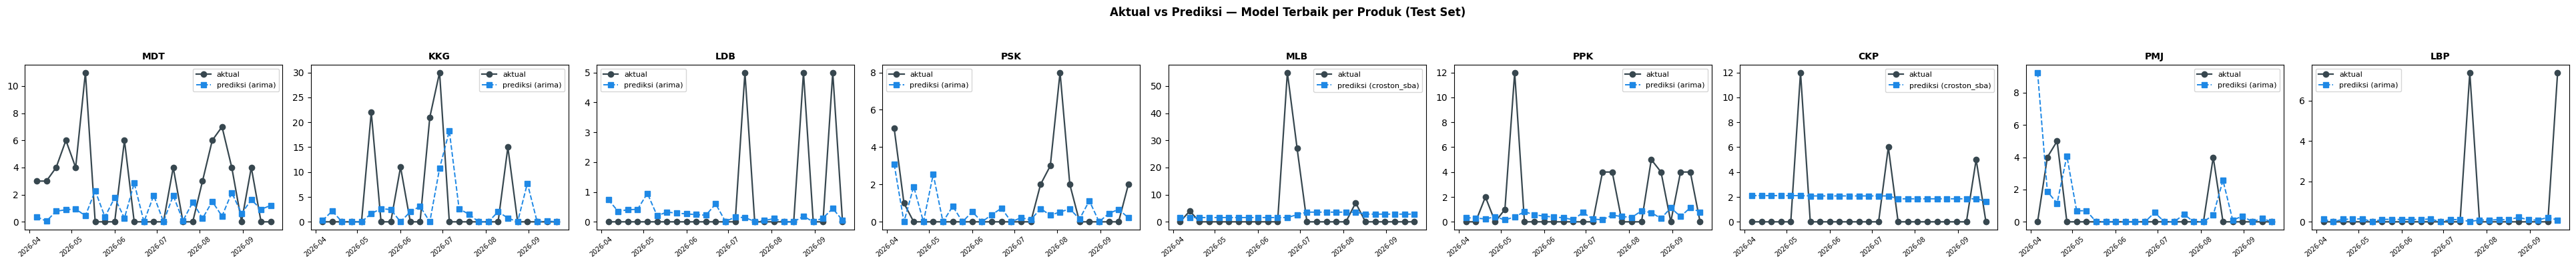

In [ ]:
fig, axes = plt.subplots(1, len(produk_model), figsize=(4 * len(produk_model), 4.2), sharey=False)
if len(produk_model) == 1:
    axes = [axes]
warna_metode = dict(zip(METODE, ['#90A4AE', '#78909C', '#5C6BC0', '#26A69A', '#EF6C00', '#8E24AA', '#AD1457', '#00897B']))
for ax, kode in zip(axes, produk_model):
    skor = SKOR_TUNING[kode]
    metodes = [m for m in METODE if m in skor]
    nilai = [skor[m] for m in metodes]
    ax.bar(metodes, nilai, color=[warna_metode[m] for m in metodes])
    terbaik = model_terbaik.loc[model_terbaik['kode_produk'] == kode, 'model_terbaik'].iloc[0]
    ax.set_title(f'{kode}\n(terbaik: {terbaik})', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.set_ylabel('RMSE (backtest di dalam train)')
fig.suptitle('Perbandingan RMSE Antar Metode Forecasting per Produk (dipilih dari backtest DI DALAM train, semakin rendah semakin baik)', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(os.path.join(OUT_DIR, 'diagram', '06_perbandingan_rmse_metode.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

fig, axes = plt.subplots(1, len(produk_model), figsize=(4.3 * len(produk_model), 4), sharex=False)
if len(produk_model) == 1:
    axes = [axes]
for ax, kode in zip(axes, produk_model):
    d = hasil_test[kode]
    terbaik = model_terbaik.loc[model_terbaik['kode_produk'] == kode, 'model_terbaik'].iloc[0]
    if not d.empty:
        ax.plot(d['minggu_mulai'], d['y_aktual'], 'o-', color='#37474F', label='aktual', lw=1.6)
        ax.plot(d['minggu_mulai'], d[terbaik], 's--', color='#1E88E5', label=f'prediksi ({terbaik})', lw=1.4)
        ax.legend(fontsize=8)
    ax.set_title(kode, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=40, labelsize=7)
fig.suptitle('Aktual vs Prediksi — Model Terbaik per Produk (Test Set)', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(os.path.join(OUT_DIR, 'diagram', '07_aktual_vs_prediksi_test.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()


### Diagram tren: aktual vs prediksi, error per minggu, dan MASE kumulatif (test set)

**Kenapa ditampilkan?** Tabel MAE/RMSE/MASE hanya memberi satu angka rata-rata untuk seluruh periode test. Diagram tren menjawab hal yang tidak terlihat dari angka itu:
1. **Aktual vs prediksi + garis tren linear** — apakah arah naik/turunnya demand yang ditangkap model searah dengan kenyataan.
2. **Tren error mingguan** — apakah model makin meleset di minggu-minggu akhir test (tren error naik), plus **bias** (aktual − prediksi): bias > 0 berarti prediksi cenderung di bawah aktual (risiko kehabisan stok), bias < 0 berarti prediksi di atas aktual (risiko stok berlebih).
3. **MASE kumulatif** — skala sama antar produk, jadi bisa dibandingkan dalam satu grafik: kurva yang mendatar di bawah garis 1 berarti akurasi stabil dan lebih baik dari tebakan naive.

Sel ini hanya membaca `hasil_test`, `model_terbaik`, dan `TRAIN_NAIVE_MAE` yang sudah ada, tanpa menghitung ulang model dan tanpa memengaruhi tuning atau pemilihan model. Slope dihitung dari urutan minggu di test; produk dengan < 3 minggu test tidak diberi garis tren (`n/a`).

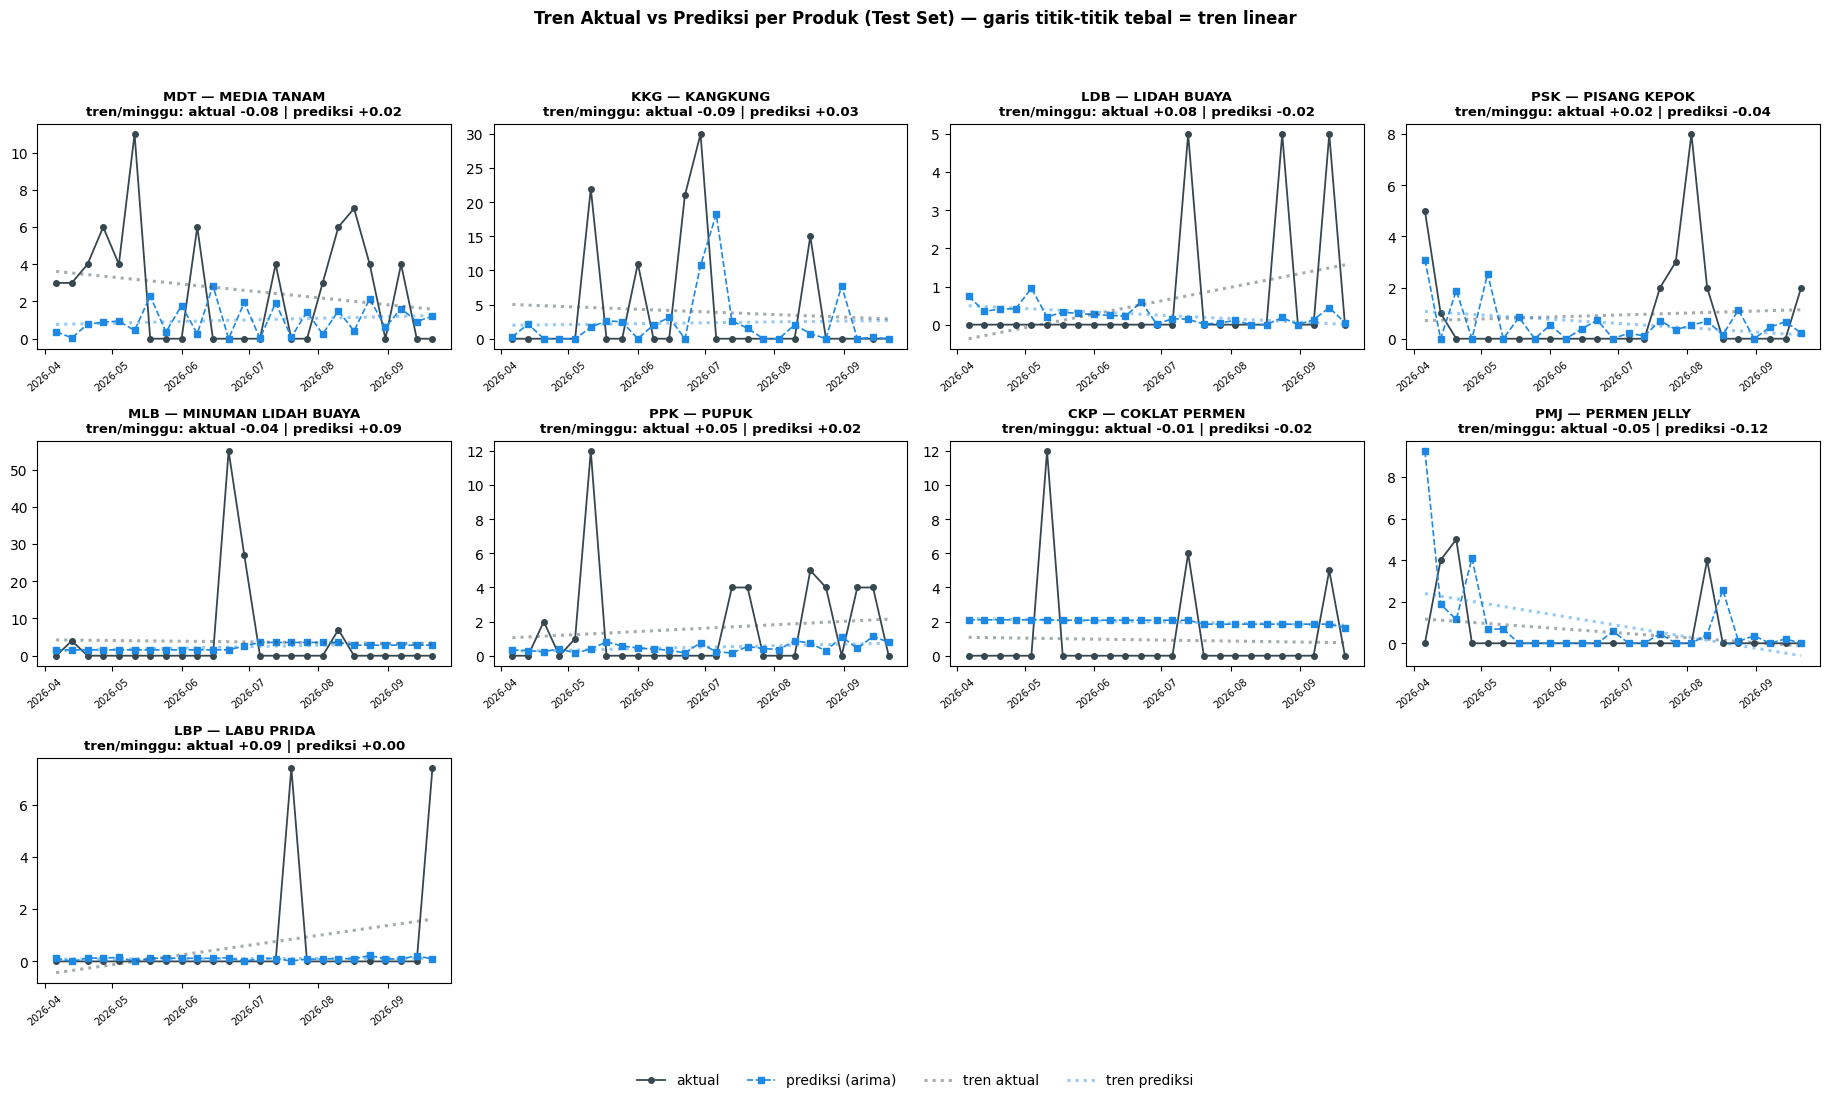

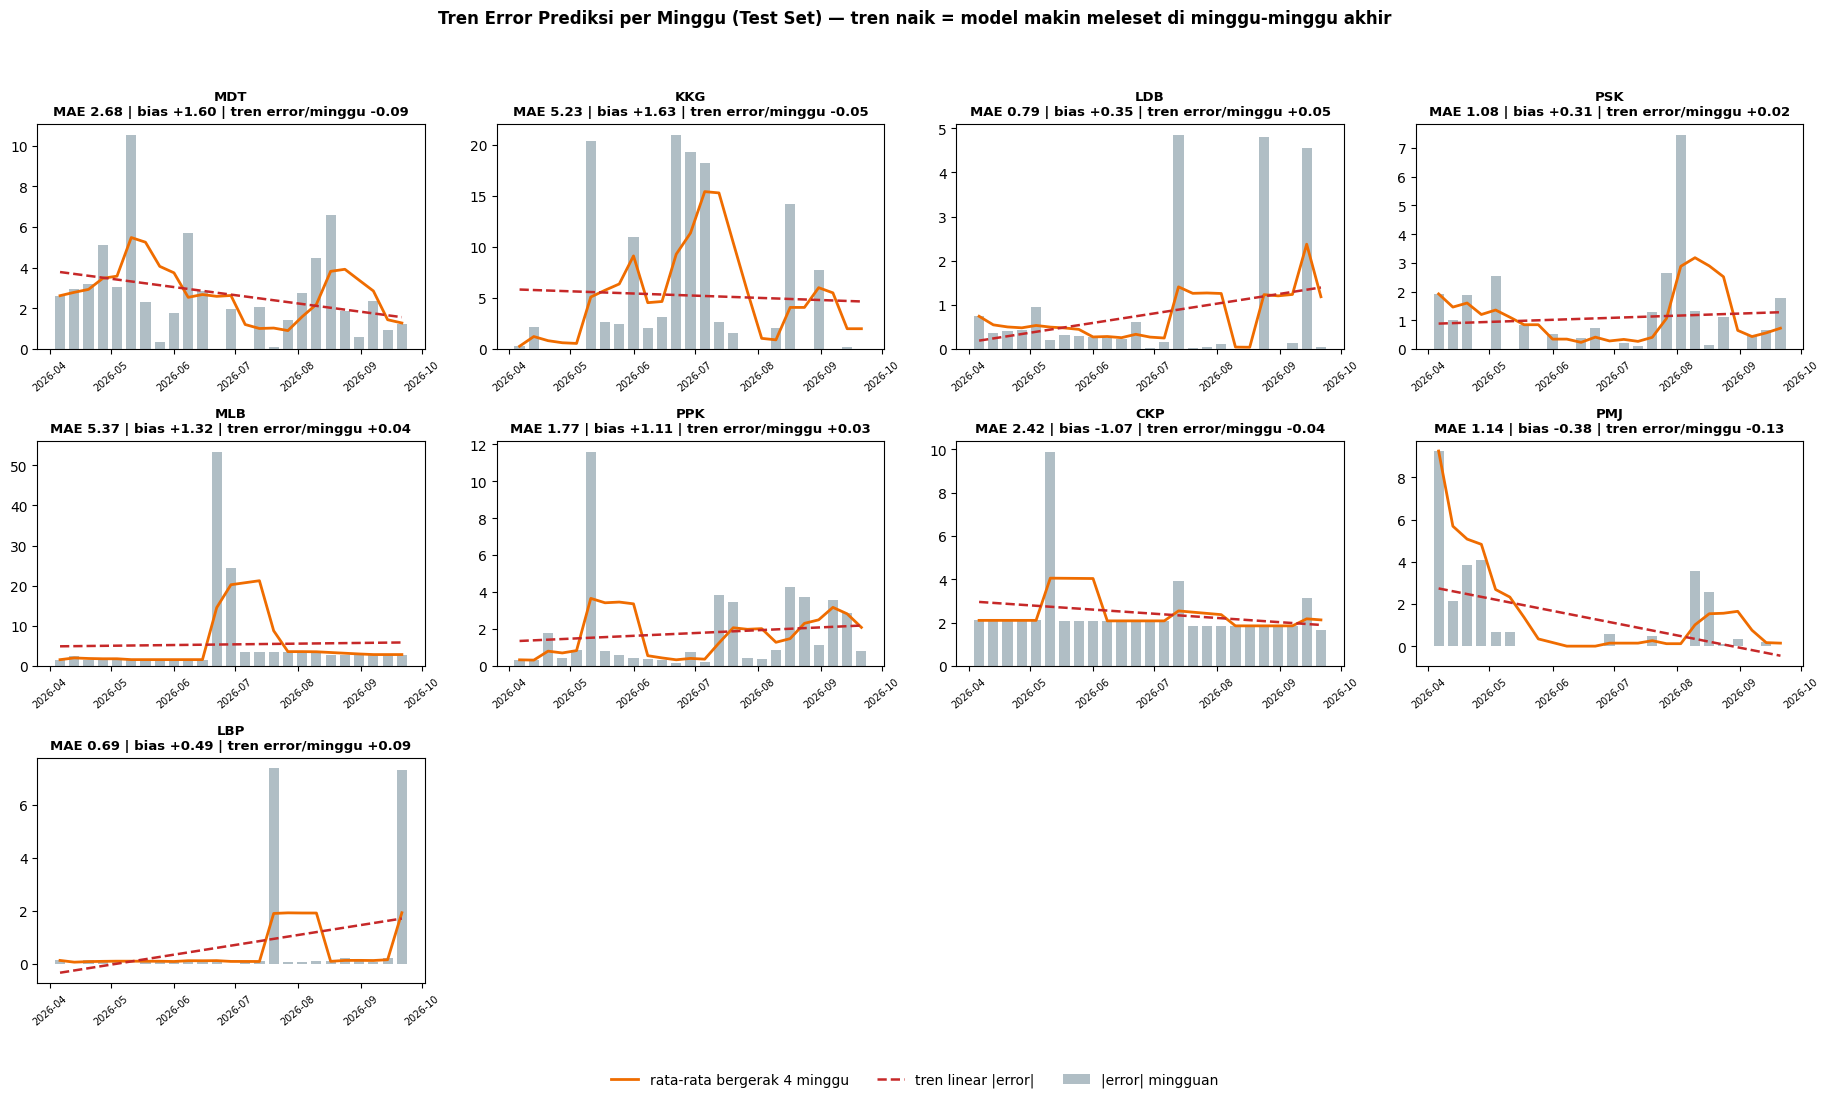

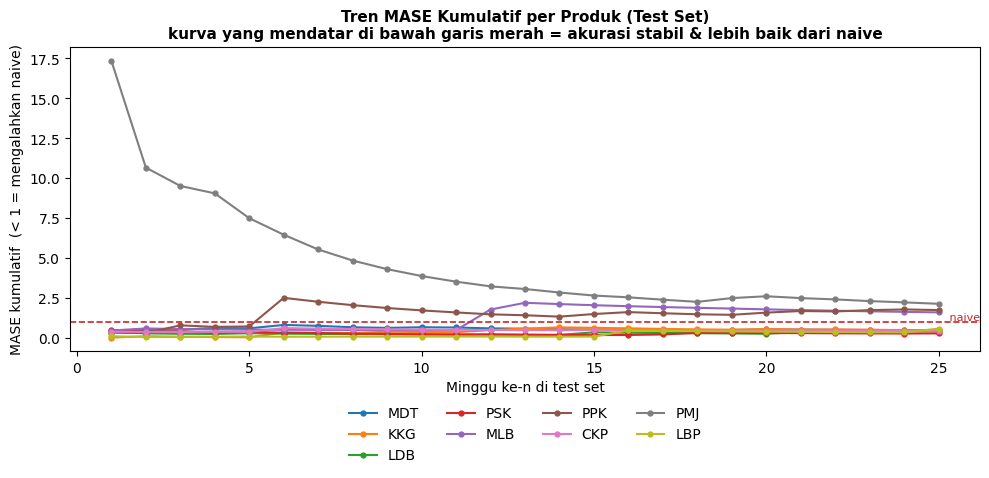

,kode_produk,model,tren_aktual_per_minggu,tren_prediksi_per_minggu,mae_test,bias_(aktual-prediksi),tren_error_per_minggu
0,MDT,arima,-0.085,0.020,2.676,1.595,-0.093
1,KKG,arima,-0.088,0.029,5.235,1.633,-0.049
2,LDB,arima,0.081,-0.020,0.790,0.348,0.050
3,PSK,arima,0.018,-0.038,1.082,0.312,0.017
4,MLB,croston_sba,-0.044,0.088,5.370,1.323,0.040
5,PPK,arima,0.045,0.020,1.770,1.105,0.035
6,CKP,croston_sba,-0.013,-0.016,2.423,-1.066,-0.044
7,PMJ,arima,-0.054,-0.125,1.141,-0.377,-0.133
8,LBP,arima,0.085,0.001,0.689,0.487,0.085


Bias > 0 : rata-rata prediksi di bawah aktual (risiko kehabisan stok). Bias < 0 : prediksi di atas aktual (risiko stok berlebih).
Tren error per minggu > 0 : error membesar seiring waktu di test. Slope dihitung dari urutan minggu di test (bukan tanggal kalender).


In [ ]:
# ---------- Diagram TREN untuk bagian Evaluasi (data: test set, model terbaik per produk) ----------
# Semua diagram di sel ini hanya membaca hasil yang sudah ada (hasil_test, model_terbaik, TRAIN_NAIVE_MAE);
# tidak ada perhitungan ulang model, dan tidak ada yang menyentuh proses tuning / pemilihan model.
produk_plot = [k for k in produk_model if not hasil_test[k].empty]
nama_produk = dict(zip(dim_produk['kode_produk'], dim_produk['nama_produk']))
n_kol = min(4, len(produk_plot))
n_baris = int(np.ceil(len(produk_plot) / n_kol))

def metode_terbaik(kode):
    return model_terbaik.loc[model_terbaik['kode_produk'] == kode, 'model_terbaik'].iloc[0]

def garis_tren(ax, tanggal, nilai, **kw):
    """Garis tren linear (OLS) pada urutan minggu. Return slope (perubahan nilai per minggu)."""
    nilai = np.asarray(nilai, dtype=float)
    if len(nilai) < 3:                       # < 3 titik: tren tidak bermakna
        return np.nan
    xi = np.arange(len(nilai))
    slope, intercept = np.polyfit(xi, nilai, 1)
    ax.plot(tanggal, intercept + slope * xi, **kw)
    return float(slope)

def fmt(v):
    return 'n/a' if v is None or np.isnan(v) else f'{v:+.2f}'

def grid_axes():
    fig, axes = plt.subplots(n_baris, n_kol, figsize=(4.6 * n_kol, 3.7 * n_baris), squeeze=False)
    axes = axes.ravel()
    for ax in axes[len(produk_plot):]:       # sembunyikan panel kosong
        ax.axis('off')
    return fig, axes

ringkas_tren = []

# ===== (1) Tren aktual vs prediksi + garis tren linear =====
fig, axes = grid_axes()
for ax, kode in zip(axes, produk_plot):
    d = hasil_test[kode].sort_values('minggu_mulai')
    m = metode_terbaik(kode)
    ax.plot(d['minggu_mulai'], d['y_aktual'], 'o-', color='#37474F', lw=1.3, ms=4, label='aktual')
    ax.plot(d['minggu_mulai'], d[m], 's--', color='#1E88E5', lw=1.2, ms=4, label=f'prediksi ({m})')
    s_akt = garis_tren(ax, d['minggu_mulai'], d['y_aktual'], color='#37474F', lw=2.2, alpha=0.45, ls=':', label='tren aktual')
    s_prd = garis_tren(ax, d['minggu_mulai'], d[m], color='#1E88E5', lw=2.2, alpha=0.45, ls=':', label='tren prediksi')
    ax.set_title(f"{kode} — {nama_produk.get(kode, '')}\ntren/minggu: aktual {fmt(s_akt)} | prediksi {fmt(s_prd)}", fontsize=9.5, fontweight='bold')
    ax.tick_params(axis='x', rotation=40, labelsize=7)
    ringkas_tren.append(dict(kode_produk=kode, model=m, slope_aktual=s_akt, slope_prediksi=s_prd))
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc='lower center', ncol=4, frameon=False)
fig.suptitle('Tren Aktual vs Prediksi per Produk (Test Set) — garis titik-titik tebal = tren linear', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.savefig(os.path.join(OUT_DIR, 'diagram', '09_tren_aktual_vs_prediksi.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ===== (2) Tren error prediksi per minggu (|aktual - prediksi|) =====
fig, axes = grid_axes()
for ax, (kode, r) in zip(axes, zip(produk_plot, ringkas_tren)):
    d = hasil_test[kode].sort_values('minggu_mulai')
    m = metode_terbaik(kode)
    err = d['y_aktual'].values - d[m].values                # > 0: aktual lebih tinggi dari prediksi (under-forecast)
    abs_err = np.abs(err)
    ax.bar(d['minggu_mulai'], abs_err, width=5, color='#B0BEC5', label='|error| mingguan')
    ax.plot(d['minggu_mulai'], pd.Series(abs_err).rolling(4, min_periods=1).mean().values,
            color='#EF6C00', lw=2, label='rata-rata bergerak 4 minggu')
    s_err = garis_tren(ax, d['minggu_mulai'], abs_err, color='#C62828', lw=1.8, ls='--', label='tren linear |error|')
    ax.set_title(f"{kode}\nMAE {abs_err.mean():.2f} | bias {err.mean():+.2f} | tren error/minggu {fmt(s_err)}", fontsize=9.5, fontweight='bold')
    ax.tick_params(axis='x', rotation=40, labelsize=7)
    r.update(mae=float(abs_err.mean()), bias=float(err.mean()), slope_abs_error=s_err)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc='lower center', ncol=3, frameon=False)
fig.suptitle('Tren Error Prediksi per Minggu (Test Set) — tren naik = model makin meleset di minggu-minggu akhir', fontsize=12, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.savefig(os.path.join(OUT_DIR, 'diagram', '10_tren_error_test.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ===== (3) Tren MASE kumulatif (skala sama antar produk, jadi bisa dibandingkan dalam satu grafik) =====
fig, ax = plt.subplots(figsize=(10, 5))
for kode in produk_plot:
    naive = TRAIN_NAIVE_MAE.get(kode, np.nan)
    if not (naive and not np.isnan(naive) and naive > 0):
        continue
    d = hasil_test[kode].sort_values('minggu_mulai')
    abs_err = np.abs(d['y_aktual'].values - d[metode_terbaik(kode)].values)
    mase_kum = (np.cumsum(abs_err) / np.arange(1, len(abs_err) + 1)) / naive
    ax.plot(np.arange(1, len(mase_kum) + 1), mase_kum, 'o-', lw=1.5, ms=3.5, label=kode)
ax.axhline(1, color='#C62828', ls='--', lw=1.2)
ax.text(ax.get_xlim()[1], 1, ' naive', color='#C62828', fontsize=8, va='bottom', ha='right')
ax.set_xlabel('Minggu ke-n di test set')
ax.set_ylabel('MASE kumulatif  (< 1 = mengalahkan naive)')
ax.set_title('Tren MASE Kumulatif per Produk (Test Set)\nkurva yang mendatar di bawah garis merah = akurasi stabil & lebih baik dari naive', fontsize=11, fontweight='bold')
ax.legend(frameon=False, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.14))
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'diagram', '11_tren_mase_kumulatif.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ===== Ringkasan angka tren =====
tren_eval = pd.DataFrame(ringkas_tren)[['kode_produk', 'model', 'slope_aktual', 'slope_prediksi', 'mae', 'bias', 'slope_abs_error']].round(3)
tren_eval.columns = ['kode_produk', 'model', 'tren_aktual_per_minggu', 'tren_prediksi_per_minggu', 'mae_test', 'bias_(aktual-prediksi)', 'tren_error_per_minggu']
display(tren_eval)
print('Bias > 0 : rata-rata prediksi di bawah aktual (risiko kehabisan stok). Bias < 0 : prediksi di atas aktual (risiko stok berlebih).')
print('Tren error per minggu > 0 : error membesar seiring waktu di test. Slope dihitung dari urutan minggu di test (bukan tanggal kalender).')

## 5. Forecast ke depan
Mendukung regresor event lewat `prediksi_satu_metode()`. Untuk minggu-minggu di luar data historis, jadwal event dianggap kosong secara default — isi `JADWAL_EVENT_KEDEPAN` di sel Setup kalau ada bazaar/mini-bazaar yang sudah direncanakan pada horizon forecast.

**Kenapa horizon-nya cuma beberapa minggu ke depan (`HORIZON_MINGGU`), bukan lebih jauh?** Setiap minggu hasil
forecast dipakai lagi sebagai "riwayat" untuk memprediksi minggu berikutnya (rekursif) — begitu prediksi mulai
sedikit meleset, kesalahan itu ikut terbawa dan membesar di minggu-minggu sesudahnya. Untuk data selumpuh ini,
horizon pendek jauh lebih bisa dipercaya daripada horizon panjang.

In [ ]:
def forecast_ke_depan(kode, n_minggu):
    g = ambil_deret(kode)
    history = list(g['y_model'].values)
    tanggal = list(g.index)
    exog_hist = [row for row in g[['ada_bazaar', 'ada_mini_bazaar']].astype(float).values]
    metode_nama = model_terbaik.loc[model_terbaik['kode_produk'] == kode, 'model_terbaik'].iloc[0]
    hasil = []
    for _ in range(n_minggu):
        tgl_baru = tanggal[-1] + pd.Timedelta(days=7)
        ev = JADWAL_EVENT_KEDEPAN.get(str(tgl_baru.date()), (0, 0))   # BARU: default tidak ada event terjadwal
        exog_future = np.array(ev, dtype=float)
        pred = prediksi_satu_metode(metode_nama, np.array(history), pd.DatetimeIndex(tanggal), kode,
                                     exog_hist=np.array(exog_hist), exog_future=exog_future)
        pred = max(pred, 0)
        hasil.append({'kode_produk': kode, 'minggu_mulai': tgl_baru, 'prediksi': pred, 'metode': metode_nama})
        history.append(pred); tanggal.append(tgl_baru); exog_hist.append(exog_future)
    return pd.DataFrame(hasil)

forecast_depan = pd.concat([forecast_ke_depan(k, HORIZON_MINGGU) for k in produk_model], ignore_index=True)
display(forecast_depan)

,kode_produk,minggu_mulai,prediksi,metode
0,MDT,2026-09-28,9.291776e-01,arima
1,MDT,2026-10-05,1.242769e+00,arima
2,MDT,2026-10-12,9.789904e-01,arima
3,MDT,2026-10-19,1.194856e+00,arima
4,KKG,2026-09-28,0.000000e+00,arima
5,KKG,2026-10-05,2.561426e-17,arima
6,KKG,2026-10-12,4.171596e-17,arima
7,KKG,2026-10-19,3.304400e-17,arima
8,LDB,2026-09-28,1.757139e-01,arima
9,LDB,2026-10-05,2.160427e-01,arima


## 6. Safety Stock & Reorder Point
Kini mencakup produk tier `penuh` **dan** `ringan` (bukan cuma tier `penuh` seperti sebelumnya).

**Kenapa perlu Safety Stock, bukan cuma andalkan angka forecast?** Forecast selalu punya error — kalau stok
hanya disiapkan sepersis angka prediksi, begitu demand aktual sedikit lebih tinggi dari prediksi, toko langsung
kehabisan stok. Safety Stock adalah "bantalan" tambahan yang besarnya disesuaikan dengan seberapa besar model
biasanya meleset (bukan angka tebakan), supaya risiko kehabisan stok bisa dikendalikan ke tingkat yang diterima.

**Kenapa rumusnya `SS = Z × σ × √(lead time)`?** ini rumus standar *safety stock* pada literatur manajemen
persediaan (didasarkan pada asumsi error demand berdistribusi normal):
- **`σ` (sigma)** = seberapa besar model biasanya salah tebak — di sini diambil dari **residual (selisih aktual
  vs prediksi) pada test set**, bukan dari mentahnya variasi demand. Ini penting: kalau modelnya bagus, error
  residual lebih kecil dari variasi demand asli, sehingga stok pengaman yang dibutuhkan juga lebih kecil —
  di sinilah akurasi model dari Tahap 4 benar-benar berdampak ke rekomendasi stok.
- **`Z`** = nilai dari distribusi normal standar yang sesuai `SERVICE_LEVEL` yang dipilih (mis. 95% -> Z≈1,645):
  makin tinggi target tingkat layanan (makin jarang mau kehabisan stok), makin besar Z, makin besar juga
  stok pengamannya — ini trade-off eksplisit antara biaya menyimpan stok lebih banyak vs risiko kehabisan.
- **`√(lead time)`** = karena error forecast terakumulasi selama barang belum datang (lead time); makin lama
  lead time, makin besar juga ketidakpastian total yang harus di-cover.

**Kenapa Reorder Point = `demand rata-rata × lead time + Safety Stock`?** Bagian pertama (`demand rata-rata ×
lead time`) adalah stok yang dibutuhkan untuk menutupi masa tunggu normal; Safety Stock ditambahkan di atasnya
sebagai bantalan untuk fluktuasi. Produk dipesan ulang begitu stok menyentuh angka ini, bukan menunggu sampai
stok benar-benar habis.

In [ ]:
def ss_rop_dari_model(kode):
    d = hasil_test[kode]
    terbaik = model_terbaik.loc[model_terbaik['kode_produk'] == kode, 'model_terbaik'].iloc[0]
    if not d.empty:
        residual = d['y_aktual'].values - d[terbaik].values
        sigma_resid = float(np.std(residual, ddof=1)) if len(residual) > 1 else float(d['y_aktual'].std(ddof=1) or 0)
    else:
        sigma_resid = float(ambil_deret(kode)['y'].std(ddof=1) or 0)
    d_rata = float(ambil_deret(kode)['y'].mean())
    lt = param_lt.loc[param_lt['kode_produk'] == kode].iloc[0]
    lt_minggu = float(lt['lead_time_minggu'])
    ss = Z_SERVICE * sigma_resid * np.sqrt(max(lt_minggu, 1e-9))
    rop = d_rata * lt_minggu + ss
    return dict(kode_produk=kode, metode_dasar=f'model ({terbaik}), sigma dari residual test',
                d_rata_minggu=d_rata, sigma_dipakai=sigma_resid, lead_time_minggu=round(lt_minggu, 3),
                sumber_lead_time=lt['sumber_lead_time'], safety_stock=max(ss, 0), reorder_point=max(rop, 0))

def ss_rop_heuristik(kode):
    g = ambil_deret(kode)
    tr = g.loc[g['split'] == 'train', 'y']
    d_rata, sigma = float(tr.mean()), float(tr.std(ddof=1) or 0)
    lt = param_lt.loc[param_lt['kode_produk'] == kode].iloc[0]
    lt_minggu = float(lt['lead_time_minggu'])
    ss = Z_SERVICE * sigma * np.sqrt(max(lt_minggu, 1e-9))
    rop = d_rata * lt_minggu + ss
    return dict(kode_produk=kode, metode_dasar='heuristik (rata-rata & std demand mentah train, TANPA model)',
                d_rata_minggu=d_rata, sigma_dipakai=sigma, lead_time_minggu=round(lt_minggu, 3),
                sumber_lead_time=lt['sumber_lead_time'], safety_stock=max(ss, 0), reorder_point=max(rop, 0))

baris_ss = [ss_rop_dari_model(k) for k in produk_model]                  # BARU: sekarang tier 'penuh' + 'ringan'
produk_lain = [k for k in dim_produk['kode_produk'] if k not in produk_model
               and profil.loc[profil['kode_produk'] == k, 'status_produk'].iloc[0] == 'aktif']
baris_ss += [ss_rop_heuristik(k) for k in produk_lain]
ss_rop = pd.DataFrame(baris_ss).merge(dim_produk[['kode_produk', 'nama_produk', 'satuan_produk']], on='kode_produk')
ss_rop = ss_rop[['kode_produk', 'nama_produk', 'satuan_produk', 'metode_dasar', 'd_rata_minggu', 'sigma_dipakai',
                 'lead_time_minggu', 'sumber_lead_time', 'safety_stock', 'reorder_point']].round(2)
ss_rop = ss_rop.sort_values('reorder_point', ascending=False)
display(ss_rop)

n_tdk_aktif = int((profil['status_produk'] != 'aktif').sum())
print(f'\n{n_tdk_aktif} produk tidak dihitung Safety Stock/ROP karena tidak terjual > {cfg.get("periode_tidak_tercatat_min_minggu","-")} '
      'minggu terakhir (lihat profil_produk.status_produk) — konfirmasi dulu apakah produk tersebut masih aktif dijual.')

,kode_produk,nama_produk,satuan_produk,metode_dasar,d_rata_minggu,sigma_dipakai,lead_time_minggu,sumber_lead_time,safety_stock,reorder_point
4,MLB,MINUMAN LIDAH BUAYA,BOTOL,"model (croston_sba), sigma dari residual test",2.22,12.18,0.29,produk (>=3 observasi valid),10.71,11.34
1,KKG,KANGKUNG,IKAT,"model (arima), sigma dari residual test",6.81,8.95,0.29,produk (>=3 observasi valid),7.87,9.81
0,MDT,MEDIA TANAM,SACK,"model (arima), sigma dari residual test",3.34,3.24,0.29,median global (data produk kurang),2.85,3.80
6,CKP,COKLAT PERMEN,GR,"model (croston_sba), sigma dari residual test",2.56,2.75,0.29,median global (data produk kurang),2.42,3.15
5,PPK,PUPUK,SACK,"model (arima), sigma dari residual test",0.81,2.84,0.29,median global (data produk kurang),2.49,2.73
3,PSK,PISANG KEPOK,SISIR,"model (arima), sigma dari residual test",2.24,1.89,0.29,median global (data produk kurang),1.66,2.30
7,PMJ,PERMEN JELLY,GR,"model (arima), sigma dari residual test",0.47,2.41,0.29,median global (data produk kurang),2.12,2.25
8,LBP,LABU PRIDA,KG,"model (arima), sigma dari residual test",0.69,2.07,0.29,median global (data produk kurang),1.82,2.01
12,JHE,JAHE,GR,heuristik (rata-rata & std demand mentah train...,0.44,2.00,0.29,median global (data produk kurang),1.76,1.89
17,KRY,KERIPIK BAYAM,GR,heuristik (rata-rata & std demand mentah train...,0.40,2.01,0.29,median global (data produk kurang),1.76,1.88



15 produk tidak dihitung Safety Stock/ROP karena tidak terjual > 4 minggu terakhir (lihat profil_produk.status_produk) — konfirmasi dulu apakah produk tersebut masih aktif dijual.


### Diagram: Safety Stock & Reorder Point per produk

**Kenapa ditampilkan?** Supaya pemilik toko bisa langsung melihat produk mana yang butuh perhatian stok paling besar, tanpa harus membaca tabel angka satu per satu.

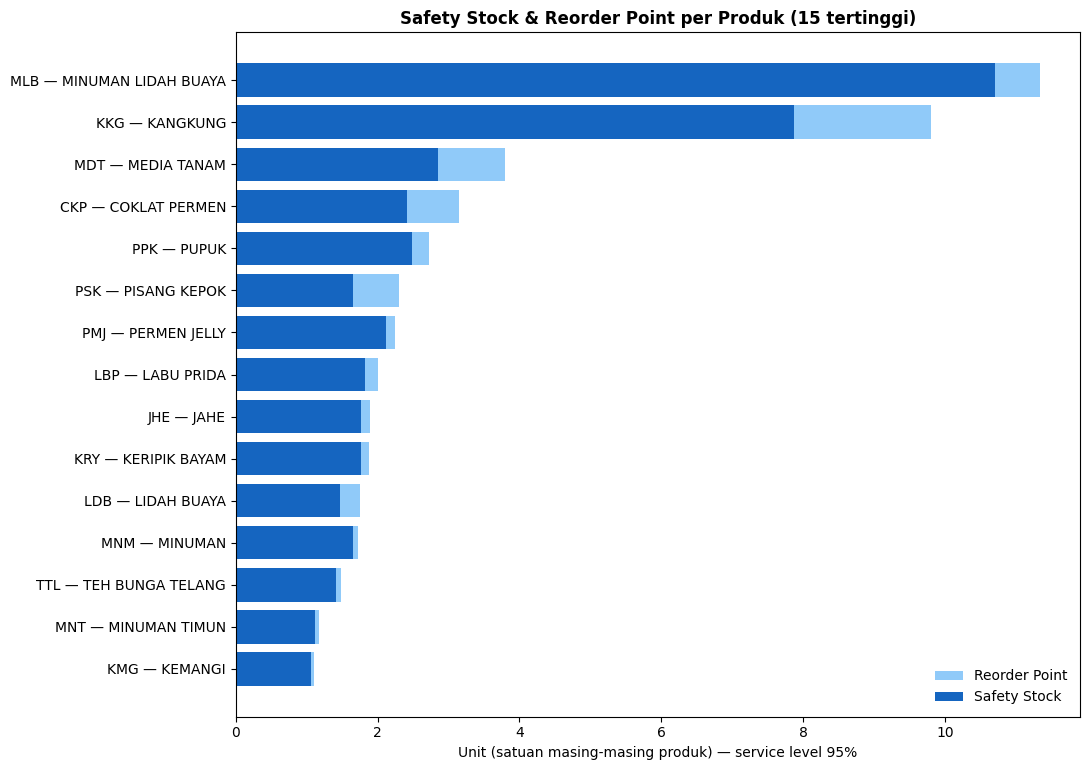

In [ ]:
d = ss_rop.head(15)
fig, ax = plt.subplots(figsize=(11, 0.42 * len(d) + 1.5))
y_pos = np.arange(len(d))
ax.barh(y_pos, d['reorder_point'], color='#90CAF9', label='Reorder Point')
ax.barh(y_pos, d['safety_stock'], color='#1565C0', label='Safety Stock')
ax.set_yticks(y_pos); ax.set_yticklabels(d['kode_produk'] + ' — ' + d['nama_produk'])
ax.invert_yaxis()
ax.set_xlabel(f'Unit (satuan masing-masing produk) — service level {SERVICE_LEVEL:.0%}')
ax.set_title('Safety Stock & Reorder Point per Produk (15 tertinggi)', fontsize=12, fontweight='bold')
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, 'diagram', '08_safety_stock_rop.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 7. Simpan hasil ke `farmsight.db`
**BARU (v3):** tabel `hyperparameter_model` dan `skor_tuning_backtest` ditambahkan untuk transparansi — hyperparameter apa yang terpilih per produk, dan skor RMSE backtest di dalam `train` yang dipakai utk memilih metode terbaik (menggantikan proses tuning di `val` pada versi sebelumnya).

In [ ]:
def siap_simpan(df):
    d = df.copy()
    for c in d.columns:
        if pd.api.types.is_datetime64_any_dtype(d[c]):
            d[c] = d[c].dt.strftime('%Y-%m-%d')
        elif d[c].dtype == bool:
            d[c] = d[c].astype(int)
    return d

hasil_test_df = pd.concat([hasil_test[k].assign(kode_produk=k) for k in produk_model if not hasil_test[k].empty], ignore_index=True)
hp_df = pd.DataFrame([{'kode_produk': k, **HP[k]} for k in produk_model])
hp_df['arima_order'] = hp_df['arima_order'].astype(str)
skor_tuning_df = pd.DataFrame([{'kode_produk': k, 'metode': m, 'rmse_backtest_train': v}
                               for k in produk_model for m, v in SKOR_TUNING[k].items()])

TABEL2 = {
    'hasil_rolling_test': hasil_test_df,
    'evaluasi_model': eval_df,
    'model_terbaik': model_terbaik,
    'forecast_kedepan': forecast_depan,
    'safety_stock_rop': ss_rop,
    'hyperparameter_model': hp_df,        # transparansi hyperparameter hasil tuning per produk
    'skor_tuning_backtest': skor_tuning_df,  # BARU (v3): skor RMSE tiap metode dari backtest di dalam train
}
for nama, df in TABEL2.items():
    siap_simpan(df).to_sql(nama, con, index=False, if_exists='replace')
    siap_simpan(df).to_csv(os.path.join(OUT_DIR, 'csv', f'{nama}.csv'), index=False)

meta = dict(cfg)
meta['pemodelan'] = dict(horizon_minggu=HORIZON_MINGGU, service_level=SERVICE_LEVEL, z_service=Z_SERVICE,
                         produk_tier_penuh=produk_layak, produk_tier_ringan=produk_ringan,
                         metode_dibandingkan=METODE, gunakan_log1p=GUNAKAN_LOG1P, pakai_regresor_event=PAKAI_REGRESOR_EVENT,
                         statsmodels_tersedia=METODE_ARIMA_TERSEDIA)
with open(os.path.join(OUT_DIR, 'config.json'), 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

con.commit()
print('Tabel tersimpan:', list(TABEL2.keys()))
for nama in TABEL2:
    n = con.execute(f'SELECT COUNT(*) FROM {nama}').fetchone()[0]
    print(f'  {nama:22s} {n} baris')
con.close()

Tabel tersimpan: ['hasil_rolling_test', 'evaluasi_model', 'model_terbaik', 'forecast_kedepan', 'safety_stock_rop', 'hyperparameter_model', 'skor_tuning_backtest']
  hasil_rolling_test     225 baris
  evaluasi_model         18 baris
  model_terbaik          9 baris
  forecast_kedepan       36 baris
  safety_stock_rop       23 baris
  hyperparameter_model   9 baris
  skor_tuning_backtest   18 baris


## Ringkasan hasil pemodelan

In [ ]:
print('=' * 70)
print('RINGKASAN PEMODELAN (VERSI DITINGKATKAN)')
print('=' * 70)
print(f"Produk dimodelkan (ARIMA/Croston): {len(produk_model)} dari {len(dim_produk)}"
      f" (tier penuh: {len(produk_layak)}, tier ringan/Croston saja: {len(produk_ringan)})")
for _, r in model_terbaik.iterrows():
    tanda = '' if r['mape_bermakna'] else '  (MAPE test tidak bermakna, minggu ber-demand terlalu sedikit)'
    mase_txt = f"MASE={r['mase']:.2f}" if pd.notna(r['mase']) else "MASE=n/a"
    print(f"  {r['kode_produk']:4s} {r['nama_produk']:22s} [{r['tier_model']:9s}] -> {r['model_terbaik']:15s} "
          f"MAE={r['mae']:.2f} RMSE={r['rmse']:.2f} MAPE={r['mape']:.1f}% {mase_txt}{tanda}")
print('\nCatatan pembacaan MASE: < 1 berarti model ini mengalahkan tebakan naive (nilai minggu lalu); > 1 berarti kalah.')
print('Model dipilih berdasarkan RMSE rolling-origin backtest DI DALAM TRAIN (tanpa validation split terpisah -- data historis sedikit);')
print('MAE/RMSE/MAPE/MASE yang ditampilkan di atas tetap dihitung HANYA dari test (tidak ikut proses pemilihan).')
print(f'\nStatsmodels tersedia: {METODE_ARIMA_TERSEDIA}')
if not METODE_ARIMA_TERSEDIA:
    print('-> Jalankan ulang notebook ini di Google Colab agar ARIMA benar-benar terlatih')
    print('   (di sandbox pengembangan ini ARIMA memakai fallback naive untuk validasi alur kode).')
print(f'\nSafety Stock/ROP dihitung untuk {len(ss_rop)} produk aktif ({len(produk_model)} berbasis model, '
      f'{len(ss_rop) - len(produk_model)} heuristik). Detail: tabel safety_stock_rop.')

RINGKASAN PEMODELAN (VERSI DITINGKATKAN)
Produk dimodelkan (ARIMA/Croston): 9 dari 38 (tier penuh: 5, tier ringan/Croston saja: 4)
  MDT  MEDIA TANAM            [penuh    ] -> arima           MAE=2.68 RMSE=3.55 MAPE=95.6% MASE=0.48
  KKG  KANGKUNG               [penuh    ] -> arima           MAE=5.23 RMSE=8.92 MAPE=198.1% MASE=0.47
  LDB  LIDAH BUAYA            [penuh    ] -> arima           MAE=0.79 RMSE=1.68 MAPE=33.5% MASE=0.42
  PSK  PISANG KEPOK           [penuh    ] -> arima           MAE=1.08 RMSE=1.87 MAPE=60.1% MASE=0.29
  MLB  MINUMAN LIDAH BUAYA    [penuh    ] -> croston_sba     MAE=5.37 RMSE=12.00 MAPE=214.3% MASE=1.60
  PPK  PUPUK                  [ringan   ] -> arima           MAE=1.77 RMSE=2.99 MAPE=64.9% MASE=1.75
  CKP  COKLAT PERMEN          [ringan   ] -> croston_sba     MAE=2.42 RMSE=2.90 MAPE=182.9% MASE=0.44
  PMJ  PERMEN JELLY           [ringan   ] -> arima           MAE=1.14 RMSE=2.39 MAPE=84.7% MASE=2.14
  LBP  LABU PRIDA             [ringan   ] -> arima       

In [ ]:
!pip freeze > requirements.txt